# Tutorial 4
- Pooled and unpooled models
- Hierarchical models
- Multi-level models


## Setup

In [ ]:
# Install Preliz only if it cannot be imported correctly

import subprocess
import sys

try:
    import preliz as pz
    print("preliz is already installed and working.")
except ModuleNotFoundError as error:
    print(f"preliz import failed because a dependency is missing: {error.name}")
    print("Installing/upgrading preliz and required dependencies...")

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "preliz",
        "arviz-base",
        "arviz-stats"
    ])

    import preliz as pz
    print("preliz installed and imported successfully.")



In [86]:
from pathlib import Path

import xarray as xr
import arviz as az
import matplotlib.pyplot as plt
import pymc as pm
import numpy as np
import pandas as pd
import seaborn as sns

from google.colab import files

In [ ]:
az.style.use("arviz-darkgrid")
sns.set_style("darkgrid")

In [ ]:
random_seed = 17

## Load data

In [4]:
# We use the larger startup dataset.
# If the file already exists in the Colab session, we read it directly.
# If not, we ask the user to upload it.


DATA_FILENAME = "big_startup_success_dataset"

# Possible file names in case the uploaded file has an extension
possible_filenames = [
    DATA_FILENAME,
    DATA_FILENAME + ".csv",
    DATA_FILENAME + ".txt",
    DATA_FILENAME + ".tsv",
]

existing_file = None

for fname in possible_filenames:
    if Path(fname).exists():
        existing_file = fname
        break

if existing_file is None:
    print("Data file was not found in the current Colab files.")
    print("Please upload the startup dataset.")

    uploaded = files.upload()

    # Take the uploaded file name
    existing_file = list(uploaded.keys())[0]
else:
    print(f"Using existing file: {existing_file}")

# Read the data
# The file looks tab-separated from the example you sent.
# sep=None lets pandas infer the separator.
df = pd.read_csv(existing_file, sep=None, engine="python")

df.head()

Data file was not found in the current Colab files.
Please upload the startup dataset.


Saving big_startup_success_dataset.csv to big_startup_success_dataset.csv


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/allone,Allone,http://www.alloneapp.com,Android|Application Platforms|Security,220000,closed,SWE,27,SWE - Other,Ängelholms Havsbad,1.0,15/03/2015,01/04/2015,01/04/2015
1,/organization/irezq,iRezQ,http://www.iRezQ.com,Mobile|Mobile Emergency&Health|SEO,150000,operating,SWE,27,SWE - Other,Åkarp,1.0,04/07/2012,20/03/2013,20/03/2013
2,/organization/ucommerce,uCommerce,http://www.ucommerce.net/,E-Commerce Platforms,597642,operating,DNK,18,DNK - Other,Århus,2.0,01/01/2008,03/04/2013,21/11/2014
3,/organization/bee-networx-astilbe,Bee Networx (Astilbe),http://www.beenetworx.com,Big Data|Media|Software,500000,operating,TUR,17,Ã‡an,Çan,1.0,NaN,26/02/2009,26/02/2009
4,/organization/beyond-the-rack,Beyond the Rack,http://www.beyondtherack.com,Fashion,98600000,operating,TUR,17,Ã‡an,Çan,7.0,01/01/2009,28/01/2010,01/10/2014


In [5]:
# Before modeling, we check that the required columns exist.

required_columns = ["name", "category_list", "country_code", "city"]

missing_columns = [col for col in required_columns if col not in df.columns]

if len(missing_columns) > 0:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

df[["name", "category_list", "country_code", "city"]].head()

Dataset shape: (66369, 14)
Columns:
['permalink', 'name', 'homepage_url', 'category_list', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'first_funding_at', 'last_funding_at']


,name,category_list,country_code,city
0,Allone,Android|Application Platforms|Security,SWE,Ängelholms Havsbad
1,iRezQ,Mobile|Mobile Emergency&Health|SEO,SWE,Åkarp
2,uCommerce,E-Commerce Platforms,DNK,Århus
3,Bee Networx (Astilbe),Big Data|Media|Software,TUR,Çan
4,Beyond the Rack,Fashion,TUR,Çan


### Create the Biotechnology variable

A startup is coded as Biotechnology if the word "Biotechnology" appears anywhere
in the category_list column.

Some startups have several categories, for example:

"Biotechnology|Medical Devices"

Therefore, we do not check for exact equality. We check whether the category list
contains the word "Biotechnology".

In [6]:
df["category_list"] = df["category_list"].astype(str).str.strip()

df["biotech"] = (
    df["category_list"]
    .str.contains("Biotechnology", case=False, na=False)
    .astype(int)
)

df[["name", "category_list", "country_code", "biotech"]].head()

,name,category_list,country_code,biotech
0,Allone,Android|Application Platforms|Security,SWE,0
1,iRezQ,Mobile|Mobile Emergency&Health|SEO,SWE,0
2,uCommerce,E-Commerce Platforms,DNK,0
3,Bee Networx (Astilbe),Big Data|Media|Software,TUR,0
4,Beyond the Rack,Fashion,TUR,0


### Create country-level grouped data

For each country:

- n_startups = total number of startups in that country
- n_biotech = number of Biotechnology startups in that country
- observed_biotech_rate = observed Biotechnology startup rate

This gives grouped data.

In [7]:
# Remove rows without country code
df_country = df.dropna(subset=["country_code"]).copy()

# Make sure country codes are clean strings
df_country["country_code"] = df_country["country_code"].astype(str).str.strip()

country_data = (
    df_country
    .groupby("country_code")
    .agg(
        n_startups=("biotech", "size"),
        n_biotech=("biotech", "sum")
    )
    .reset_index()
)

country_data["observed_biotech_rate"] = (
    country_data["n_biotech"] / country_data["n_startups"]
)

country_data = country_data.sort_values("n_startups", ascending=False).reset_index(drop=True)

country_data.head()

,country_code,n_startups,n_biotech,observed_biotech_rate
0,USA,37601,3342,0.088881
1,GBR,3688,235,0.063720
2,CAN,1925,147,0.076364
3,IND,1596,22,0.013784
4,CHN,1544,47,0.030440


### Cleaning the data file - Keep countries with enough data

Countries with very few startups can have extreme observed rates only because of noise.

To keep the tutorial readable, we keep countries with at least 30 startups.

In [8]:
min_startups_per_country = 30

country_data_filtered = (
    country_data[country_data["n_startups"] >= min_startups_per_country]
    .copy()
    .reset_index(drop=True)
)

print(f"Number of countries before filtering: {len(country_data)}")
print(f"Number of countries after filtering: {len(country_data_filtered)}")

country_data_filtered.head()

Number of countries before filtering: 137
Number of countries after filtering: 59


,country_code,n_startups,n_biotech,observed_biotech_rate
0,USA,37601,3342,0.088881
1,GBR,3688,235,0.063720
2,CAN,1925,147,0.076364
3,IND,1596,22,0.013784
4,CHN,1544,47,0.030440


### Plot the observed Biotechnology startup rates

These are raw observed rates.
They are not yet model estimates.

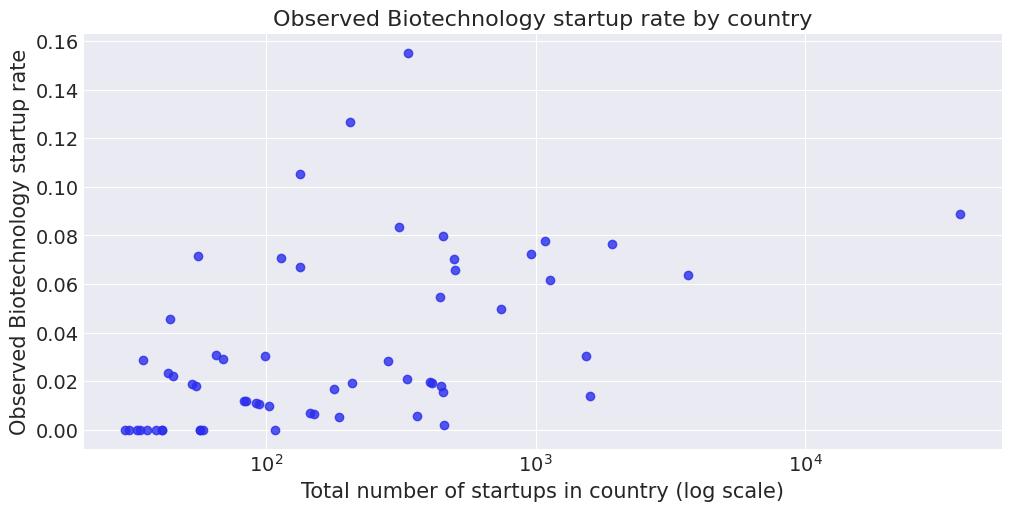

In [9]:
plt.figure(figsize=(10, 5))

plt.scatter(
    country_data_filtered["n_startups"],
    country_data_filtered["observed_biotech_rate"],
    alpha=0.8
)

plt.xscale("log")
plt.xlabel("Total number of startups in country (log scale)")
plt.ylabel("Observed Biotechnology startup rate")
plt.title("Observed Biotechnology startup rate by country")

plt.show()

### Prepare variables for PyMC

We now create the variables for the Beta-Binomial models.

For each country:

- n_startups is the number of trials
- n_biotech is the number of successes
- theta is the probability that a startup is Biotechnology

Number of countries: 59
Total startups in model: 59008
Total Biotechnology startups in model: 4399
Overall observed Biotechnology rate: 0.0745


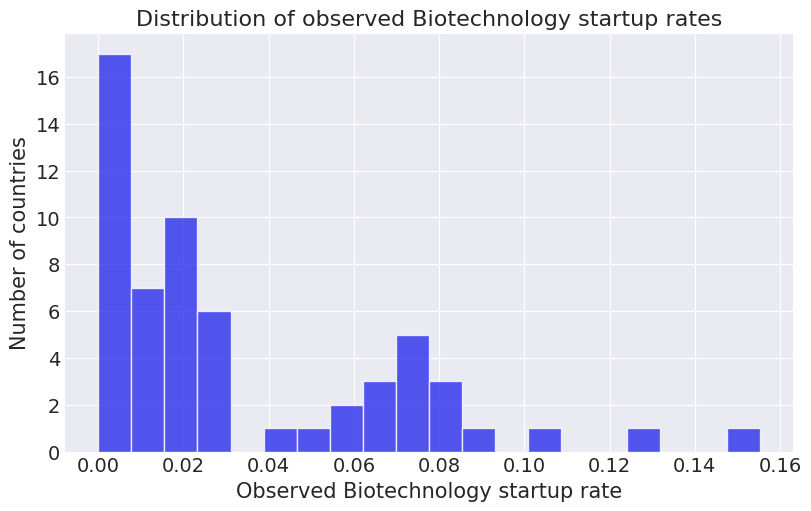

In [10]:
# Define variables
country_names = country_data_filtered["country_code"].to_numpy()

n_startups = country_data_filtered["n_startups"].to_numpy()
n_biotech = country_data_filtered["n_biotech"].to_numpy()

observed_rate = country_data_filtered["observed_biotech_rate"].to_numpy()

n_countries = len(country_names)

coords = {
    "country": country_names
}

print(f"Number of countries: {n_countries}")
print(f"Total startups in model: {n_startups.sum()}")
print(f"Total Biotechnology startups in model: {n_biotech.sum()}")
print(f"Overall observed Biotechnology rate: {n_biotech.sum() / n_startups.sum():.4f}")

# Plot the distribution of observed country rates

plt.figure(figsize=(8, 5))

plt.hist(
    observed_rate,
    bins=20,
    edgecolor="white",
    alpha=0.8
)

plt.xlabel("Observed Biotechnology startup rate")
plt.ylabel("Number of countries")
plt.title("Distribution of observed Biotechnology startup rates")

plt.show()

### Helper function for predictive rate plots

`az.plot_ppc()` compares the predicted counts of Biotechnology startups.

Because our interpretation focuses on rates, we also plot predictive rates by dividing the predicted counts by the total number of startups in each group.

In [11]:
def plot_predictive_rates(idata, group_name, n_trials, observed_rates, title):
    """
    Plot predictive rates from prior predictive or posterior predictive samples.

    The model predicts counts:
        z ~ Binomial(n, theta)

    We convert predictive counts to rates:
        predictive rate = predictive z / n
    """

    predictive_z = az.extract(
        idata,
        group=group_name,
        var_names="z"
    )

    predictive_rate = predictive_z / n_trials[:, None]

    plt.figure(figsize=(8, 5))

    plt.hist(
        predictive_rate.values.ravel(),
        bins=30,
        density=True,
        alpha=0.5,
        label="Predictive rates"
    )

    plt.hist(
        observed_rates,
        bins=30,
        density=True,
        histtype="step",
        linewidth=2,
        label="Observed rates"
    )

    plt.xlabel("Biotechnology startup rate")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.show()

### Helper function for posterior plotting

In [84]:
# ------------------------------------------------------------
# Posterior density plots for pooled, unpooled, hierarchical,
# and multi-level models
# ------------------------------------------------------------

from matplotlib.lines import Line2D


def posterior_samples_1d(idata, var_name, dim_name=None, coord_value=None):
    """
    Extract posterior samples as a 1D NumPy array.

    Parameters
    ----------
    idata : arviz.InferenceData
        Model output from pm.sample().
    var_name : str
        Name of posterior parameter, for example "theta".
    dim_name : str or None
        Coordinate dimension, for example "country" or "city".
        Use None for scalar parameters.
    coord_value : str or None
        Specific coordinate value to select.

    Returns
    -------
    samples : np.ndarray
        Posterior samples collapsed across chains and draws.
    """

    da = idata.posterior[var_name]

    if dim_name is not None and coord_value is not None:
        da = da.sel({dim_name: coord_value})

    samples = da.stack(sample=("chain", "draw")).values
    return np.asarray(samples).ravel()


def finish_density_plot(ax, title, xlabel="Biotechnology startup probability", xlim=(0, 0.20)):
    """
    Apply common formatting to posterior density plots.
    """

    ax.set_title(title, fontsize=16)
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel("posterior density", fontsize=13)
    ax.set_xlim(xlim)
    ax.grid(axis="x", color="0.85", linewidth=1)
    ax.grid(axis="y", visible=False)


def plot_pooled_density(idata, xlim=(0, 0.20)):
    """
    Plot posterior density for the pooled model.
    The pooled model has one theta parameter shared by all countries.
    """

    samples = posterior_samples_1d(idata, var_name="theta")

    fig, ax = plt.subplots(figsize=(8, 4.5))

    az.plot_kde(
        samples,
        ax=ax,
        plot_kwargs={
            "linewidth": 2.5,
            "label": r"$\theta$"
        }
    )

    finish_density_plot(
        ax,
        title="pooled",
        xlim=xlim
    )

    ax.legend(frameon=False)
    plt.show()


def plot_group_theta_densities(
    idata,
    group_names,
    dim_name,
    title,
    max_groups=6,
    xlim=(0, 0.20),
    alpha=0.95,
    linewidth=2.5
):
    """
    Plot posterior density curves for group-level theta parameters.

    Use this for:
    - unpooled country-level theta
    - hierarchical country-level theta
    """

    groups_to_plot = np.asarray(group_names[:max_groups])

    colors = plt.cm.tab10(np.linspace(0, 1, len(groups_to_plot)))

    fig, ax = plt.subplots(figsize=(8, 4.5))

    for group, color in zip(groups_to_plot, colors):
        samples = posterior_samples_1d(
            idata,
            var_name="theta",
            dim_name=dim_name,
            coord_value=group
        )

        az.plot_kde(
            samples,
            ax=ax,
            plot_kwargs={
                "color": color,
                "linewidth": linewidth,
                "alpha": alpha,
                "label": str(group)
            }
        )

    finish_density_plot(
        ax,
        title=title,
        xlim=xlim
    )

    ax.legend(
        title=dim_name,
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

def plot_multilevel_by_country(
    idata,
    city_names,
    city_country,
    n_countries=4,
    selected_countries=None,
    max_cities_per_country=None,
    xlim=(0, 0.20),
    ylim=None,
    figsize=(7, 4),
    alpha=0.65,
    linewidth=2.0,
    palette="tab10",
):
    """
    Plot city-level posterior theta densities from a multi-level model.

    Creates one separate plot per country.
    Each plot shows the posterior densities of cities from that country.
    All plots use the same x-axis and y-axis scales.

    Important:
    xlim controls the visible plotting range only.
    It does not truncate posterior samples.
    """

    city_names = np.asarray(city_names)
    city_country = np.asarray(city_country)

    # Choose countries
    if selected_countries is None:
        # Countries ordered by number of cities, descending
        country_counts = pd.Series(city_country).value_counts()
        countries_to_plot = country_counts.index[:n_countries].to_numpy()
    else:
        countries_to_plot = np.asarray(selected_countries)

    # First pass:
    # compute KDEs and find a shared y-axis limit
    kde_store = {}
    global_ymax = 0

    for country in countries_to_plot:
        country_mask = city_country == country
        cities_in_country = city_names[country_mask]

        if max_cities_per_country is not None:
            cities_in_country = cities_in_country[:max_cities_per_country]

        kde_store[country] = {}

        for city in cities_in_country:
            samples = (
                idata.posterior["theta"]
                .sel(city=city)
                .stack(sample=("chain", "draw"))
                .values
                .ravel()
            )

            # Do NOT use custom_lims here.
            # Some posterior samples may be outside xlim.
            kde_x, kde_y = az.kde(samples)

            kde_store[country][city] = (kde_x, kde_y)

            # Use only the visible x-range to determine the shared y-axis scale
            visible_mask = (kde_x >= xlim[0]) & (kde_x <= xlim[1])

            if np.any(visible_mask):
                global_ymax = max(global_ymax, np.max(kde_y[visible_mask]))
            else:
                global_ymax = max(global_ymax, np.max(kde_y))

    if global_ymax == 0:
        global_ymax = 1

    if ylim is None:
        shared_ylim = (0, global_ymax * 1.10)
    else:
        shared_ylim = ylim

    # Second pass:
    # plot one figure per country
    cmap = plt.get_cmap(palette)

    for country in countries_to_plot:
        cities_in_plot = list(kde_store[country].keys())

        if len(cities_in_plot) == 0:
            print(f"No cities found for country: {country}")
            continue

        colors = cmap(np.linspace(0, 1, max(len(cities_in_plot), 2)))

        fig, ax = plt.subplots(figsize=figsize)

        for city, color in zip(cities_in_plot, colors):
            kde_x, kde_y = kde_store[country][city]

            ax.plot(
                kde_x,
                kde_y,
                color=color,
                linewidth=linewidth,
                alpha=alpha,
                label=str(city),
            )

        ax.set_title(f"multi-level: {country}", fontsize=16)
        ax.set_xlabel("Biotechnology startup probability", fontsize=13)
        ax.set_ylabel("posterior density", fontsize=13)

        # This controls the visible scale only
        ax.set_xlim(xlim)
        ax.set_ylim(shared_ylim)

        ax.grid(axis="x", color="0.85", linewidth=1)
        ax.grid(axis="y", visible=False)

        ax.legend(
            title="city",
            frameon=False,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=8,
            title_fontsize=9,
        )

        plt.tight_layout()
        plt.show()

    plt.tight_layout()
    plt.show()

## 1. Pooled model

The pooled model ignores the country structure.
It estimates one Biotechnology startup probability for all countries.

Model:

theta ~ Beta(alpha, beta)

z_i ~ Binomial(n_i, theta)

where:
- n_i is the total number of startups in country i
- z_i is the number of Biotechnology startups in country i
- theta is one shared Biotechnology startup probability

omega_alpha = 2.880
omega_beta = 27.003
Prior mean = 0.096


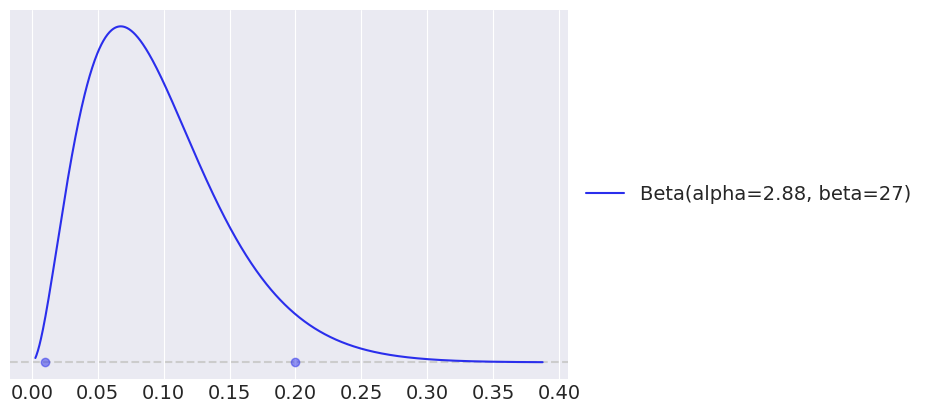

In [14]:
# Prior
# Choose a weakly informed prior for the global Biotechnology startup rate.
# We expect the rate to usually be between 1% and 20%.

biotech_rate_prior, ax = pz.maxent(
    pz.Beta(),
    lower=0.01,
    upper=0.20,
    mass=0.95,
    plot=True
)

omega_alpha = float(biotech_rate_prior.alpha)
omega_beta = float(biotech_rate_prior.beta)

print(f"omega_alpha = {omega_alpha:.3f}")
print(f"omega_beta = {omega_beta:.3f}")
print(f"Prior mean = {omega_alpha / (omega_alpha + omega_beta):.3f}")


In [15]:
# Pooled Beta-Binomial model
coords = {"country": country_names}

with pm.Model(coords=coords) as pooled_model:
    # prior
    theta = pm.Beta("theta", alpha=omega_alpha, beta=omega_beta)
    # likelihood
    z = pm.Binomial("z", n=n_startups, p=theta, observed=n_biotech, dims="country")

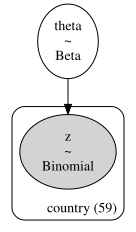

In [16]:
pm.model_to_graphviz(pooled_model)

### Prior predictive check

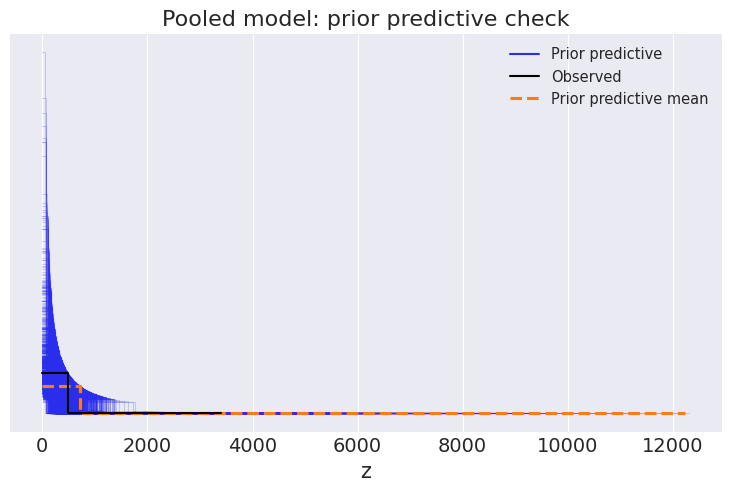

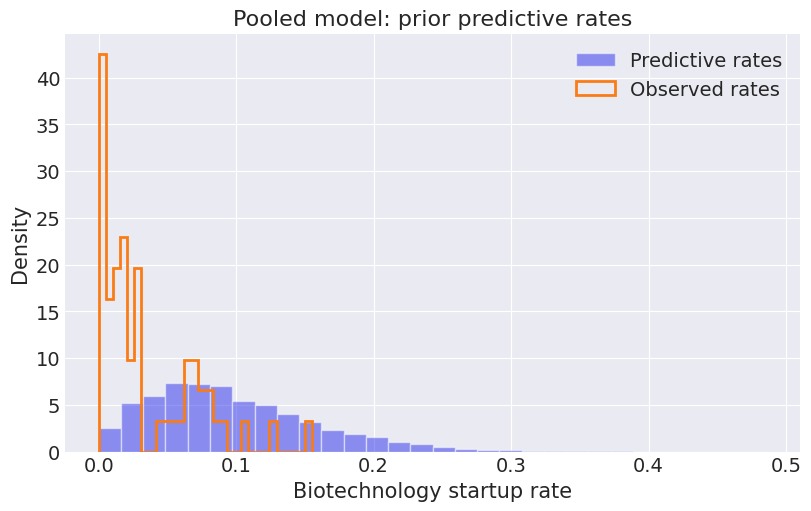

In [17]:
# Prior predictive check
with pooled_model:
    idata_pooled_prior = pm.sample_prior_predictive(
        samples=1000,
        random_seed=random_seed
    )

idata_pooled_prior

# Prior predictive plot
az.plot_ppc(
    idata_pooled_prior,
    group="prior",
    observed=True
)

plt.title("Pooled model: prior predictive check")
plt.show()

plot_predictive_rates(
    idata=idata_pooled_prior,
    group_name="prior_predictive",
    n_trials=n_startups,
    observed_rates=observed_rate,
    title="Pooled model: prior predictive rates"
)

### Sample and diagnostics

In [18]:
# Sample
with pooled_model:
    idata_pooled = pm.sample(
        draws=1000,
        chains=4,
        random_seed=random_seed)
idata_pooled

Output()

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [19]:
# posterior summary
az.summary(
    idata_pooled,
    kind="diagnostics",
    var_names=["theta"]
)


,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.0,0.0,1542.0,2359.0,1.0


Number of divergences: 0


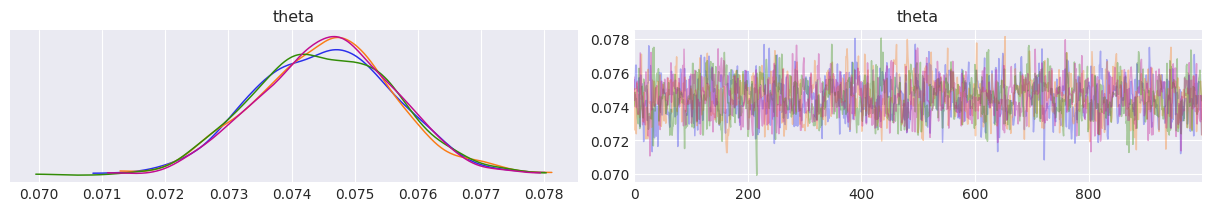

In [20]:
# Diagnostics
az.plot_trace(
    idata_pooled,
    var_names=["theta"],
    compact=False
)

pooled_divergences = idata_pooled.sample_stats["diverging"].sum().values
print(f"Number of divergences: {pooled_divergences}")

### Posterior predictive check

Output()

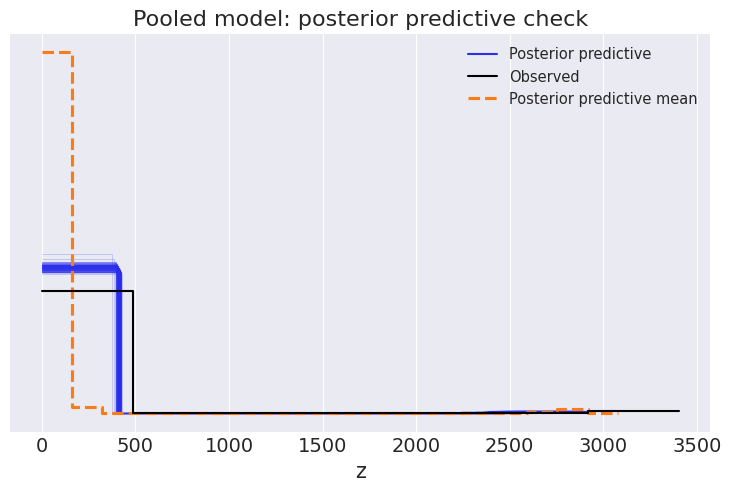

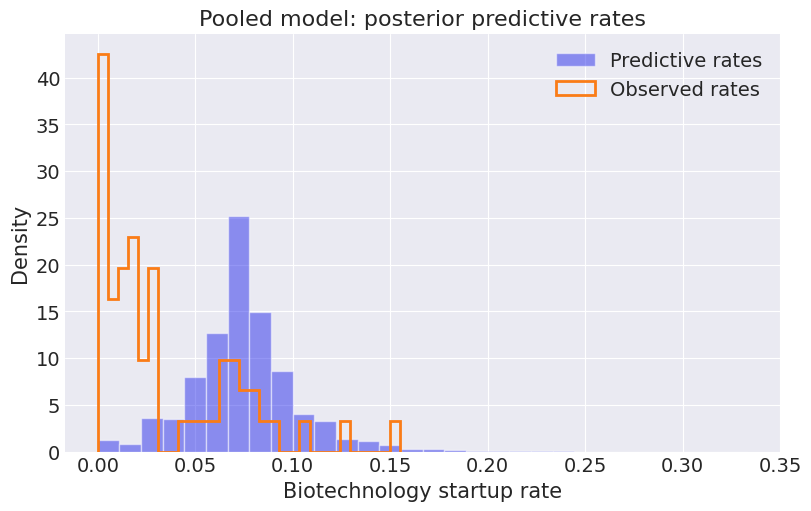

In [21]:
# Posterior predictive check

with pooled_model:
    idata_pooled = pm.sample_posterior_predictive(
        idata_pooled,
        var_names=["z"],
        random_seed=random_seed,
        extend_inferencedata=True
    )

az.plot_ppc(
    idata_pooled,
    group="posterior",
    observed=True,
    num_pp_samples=100
)

plt.title("Pooled model: posterior predictive check")
plt.show()

plot_predictive_rates(
    idata=idata_pooled,
    group_name="posterior_predictive",
    n_trials=n_startups,
    observed_rates=observed_rate,
    title="Pooled model: posterior predictive rates"
)

### Posterior

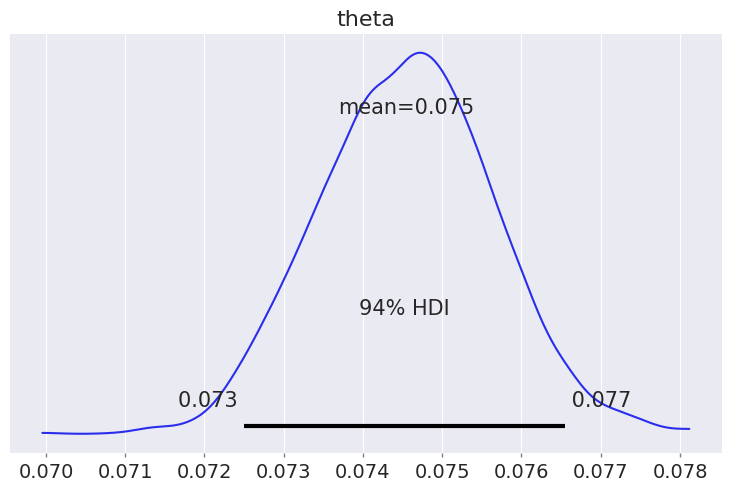

In [22]:
# Posterior plot
az.plot_posterior(
    idata_pooled,
    var_names=["theta"])

plt.show()

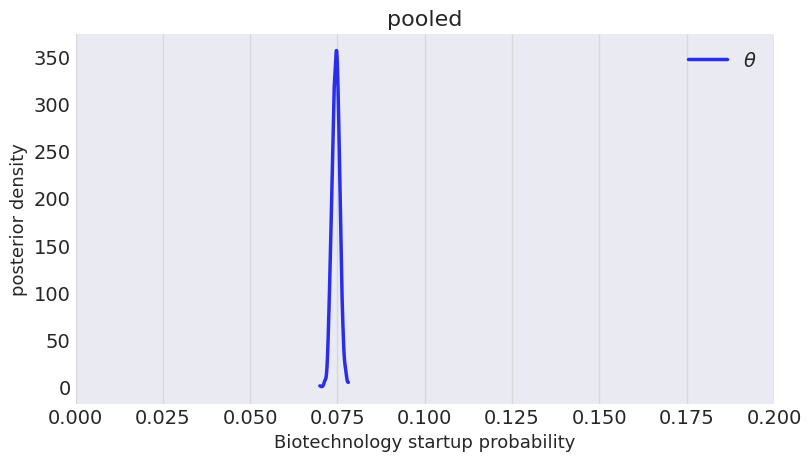

In [23]:
# Pooled model: one shared theta
plot_pooled_density(
    idata_pooled,
    xlim=(0, 0.20)
)

## 2. Unpooled model
The unpooled model estimates a separate Biotechnology startup probability for each country.

There is no information sharing between countries.

In [24]:
coords = {"country": country_names}

with pm.Model(coords=coords) as unpooled_model:
    # prior
    theta = pm.Beta(
        "theta",
        alpha=omega_alpha,
        beta=omega_beta,
        dims="country")

    # likelihood
    z = pm.Binomial(
        "z",
        n=n_startups,
        p=theta,
        observed=n_biotech,
        dims="country")


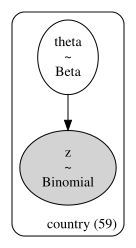

In [25]:
pm.model_to_graphviz(unpooled_model)

### Prior predictive check

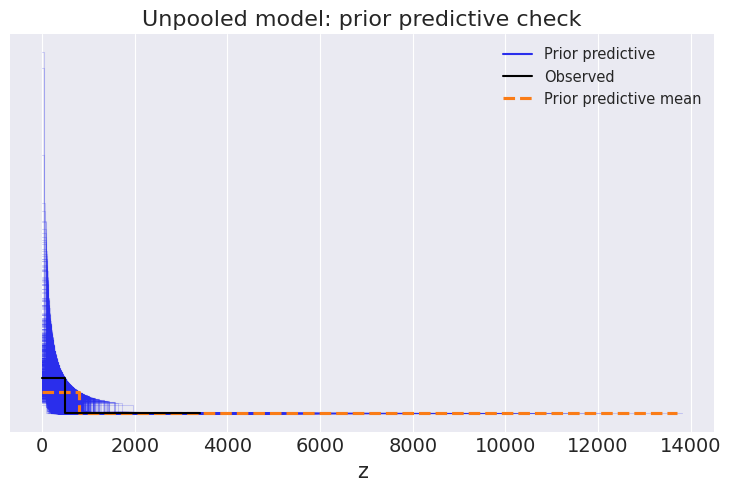

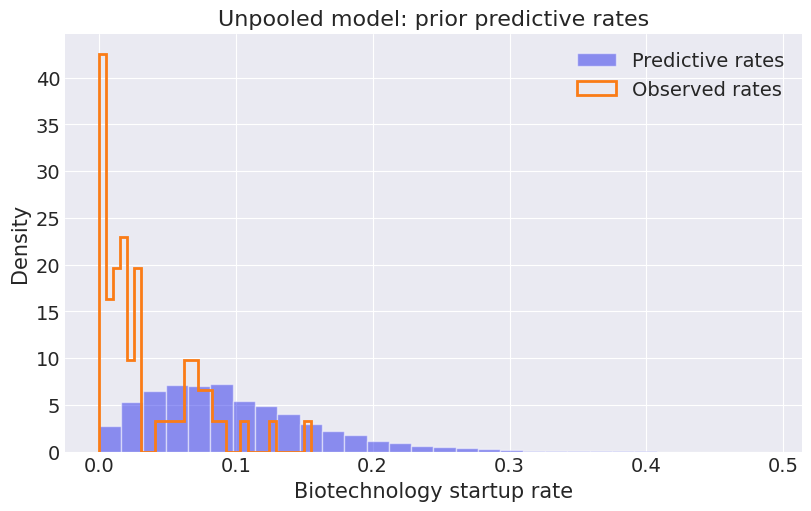

In [26]:
with unpooled_model:
    idata_unpooled_prior = pm.sample_prior_predictive(
        samples=1000,
        random_seed=random_seed
    )

az.plot_ppc(
    idata_unpooled_prior,
    group="prior",
    observed=True
)

plt.title("Unpooled model: prior predictive check")
plt.show()

plot_predictive_rates(
    idata=idata_unpooled_prior,
    group_name="prior_predictive",
    n_trials=n_startups,
    observed_rates=observed_rate,
    title="Unpooled model: prior predictive rates"
)

### Sample and diagnostics

In [27]:
with unpooled_model:
    idata_unpooled = pm.sample(
        draws=1000,
        chains=4,
        random_seed=random_seed,
        target_accept=0.9
    )

idata_unpooled

Output()

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [28]:
# Check which groups are stored in the InferenceData object
idata_unpooled.groups()

az.summary(
    idata_unpooled,
    kind="diagnostics",
    var_names=["theta"]
)


,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta[USA],0.0,0.000,8831.0,2958.0,1.00
theta[GBR],0.0,0.000,6977.0,2615.0,1.00
theta[CAN],0.0,0.000,8343.0,2655.0,1.00
theta[IND],0.0,0.000,7320.0,2620.0,1.00
theta[CHN],0.0,0.000,7976.0,2774.0,1.00
theta[FRA],0.0,0.000,8621.0,2896.0,1.00
theta[DEU],0.0,0.000,8094.0,2999.0,1.00
theta[ISR],0.0,0.000,7743.0,2518.0,1.00
theta[ESP],0.0,0.000,7806.0,2948.0,1.00
theta[AUS],0.0,0.000,7732.0,2810.0,1.00


/tmp/ipykernel_590/3603398410.py:10: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.8)


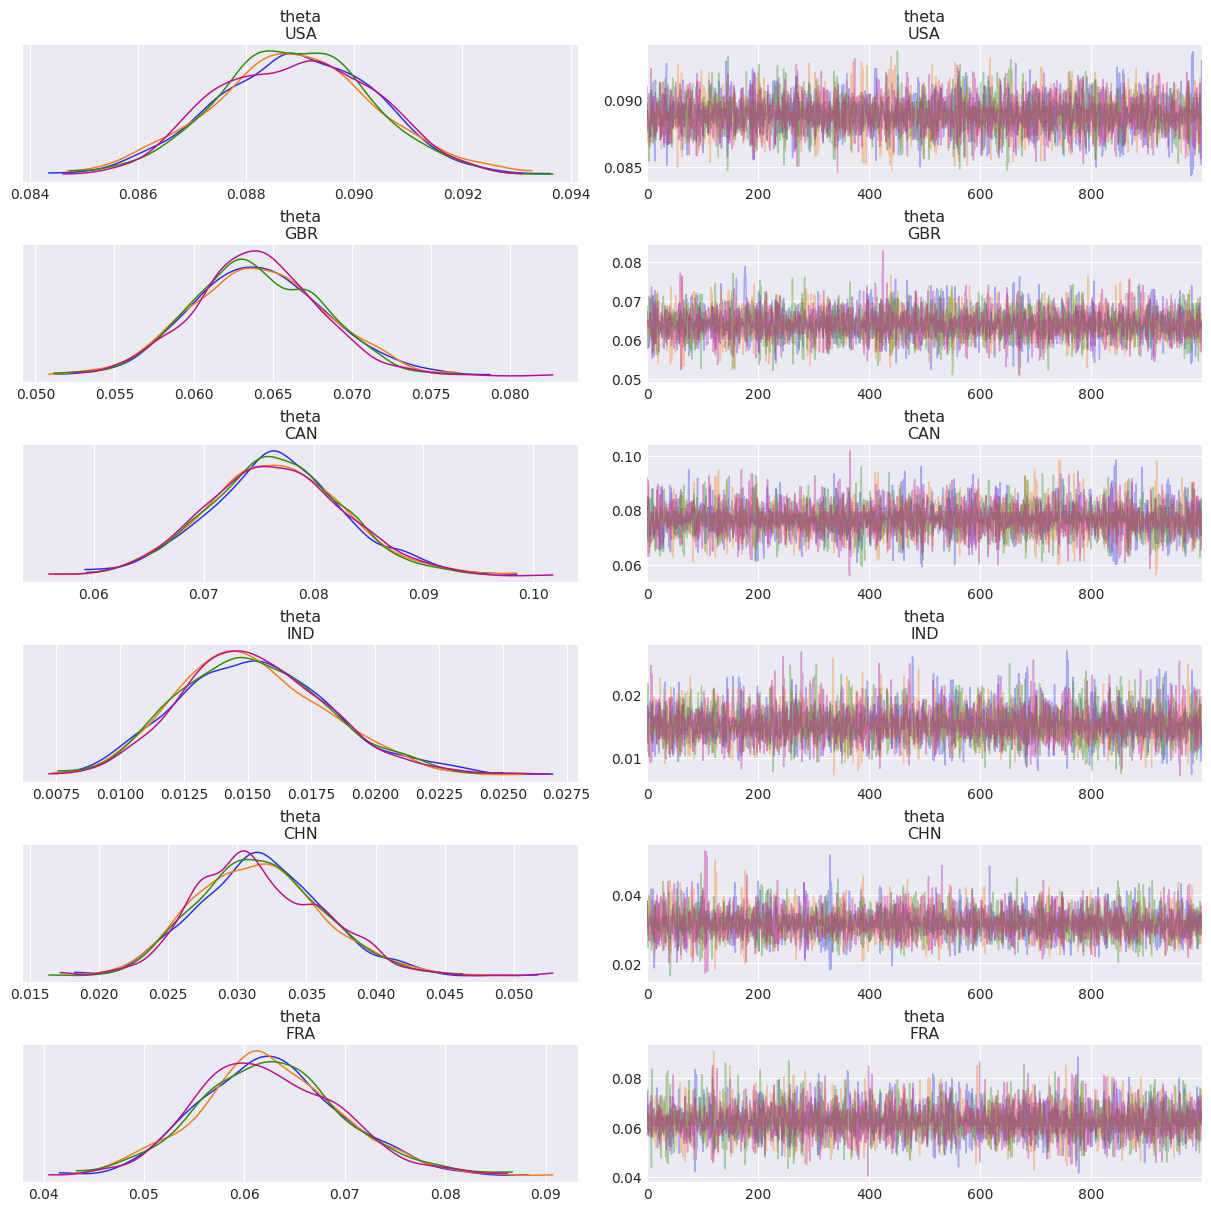

Number of divergences: 0


In [29]:
# Plot only the first few countries, because plotting all countries can be too crowded.

az.plot_trace(
    idata_unpooled,
    var_names=["theta"],
    coords={"country": country_names[:6]},
    compact=False
)

plt.subplots_adjust(hspace=0.8)
plt.show()

unpooled_divergences = idata_unpooled.sample_stats["diverging"].sum().values
print(f"Number of divergences: {unpooled_divergences}")

### Posterior predictive check

Output()

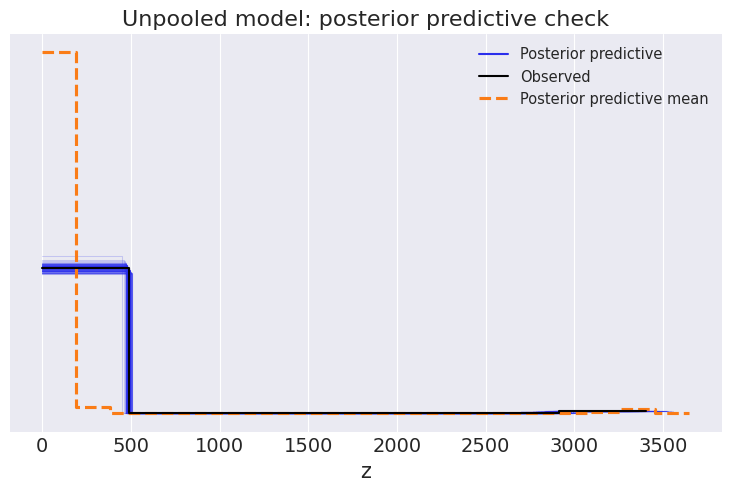

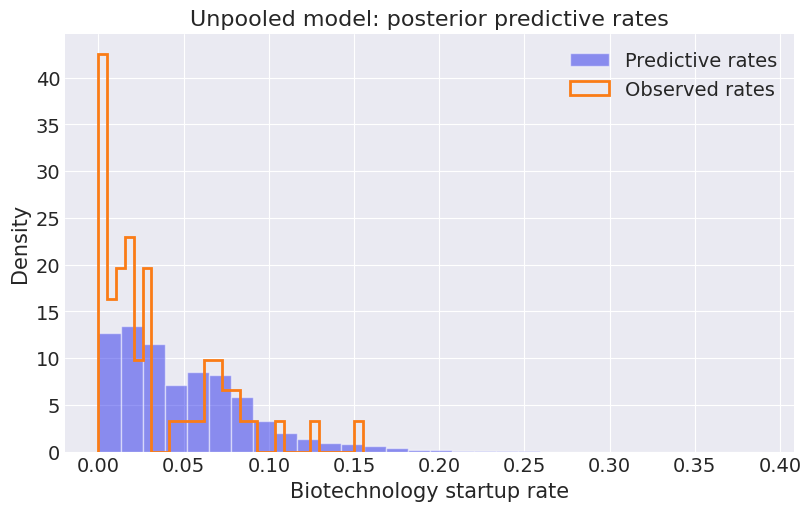

In [30]:
with unpooled_model:
    idata_unpooled = pm.sample_posterior_predictive(
        idata_unpooled,
        var_names=["z"],
        random_seed=random_seed,
        extend_inferencedata=True
    )

# Check which groups are stored in the InferenceData object
idata_unpooled.groups()

az.plot_ppc(
    idata_unpooled,
    group="posterior",
    observed=True,
    num_pp_samples=100
)

plt.title("Unpooled model: posterior predictive check")
plt.show()

plot_predictive_rates(
    idata=idata_unpooled,
    group_name="posterior_predictive",
    n_trials=n_startups,
    observed_rates=observed_rate,
    title="Unpooled model: posterior predictive rates"
)

### Posterior

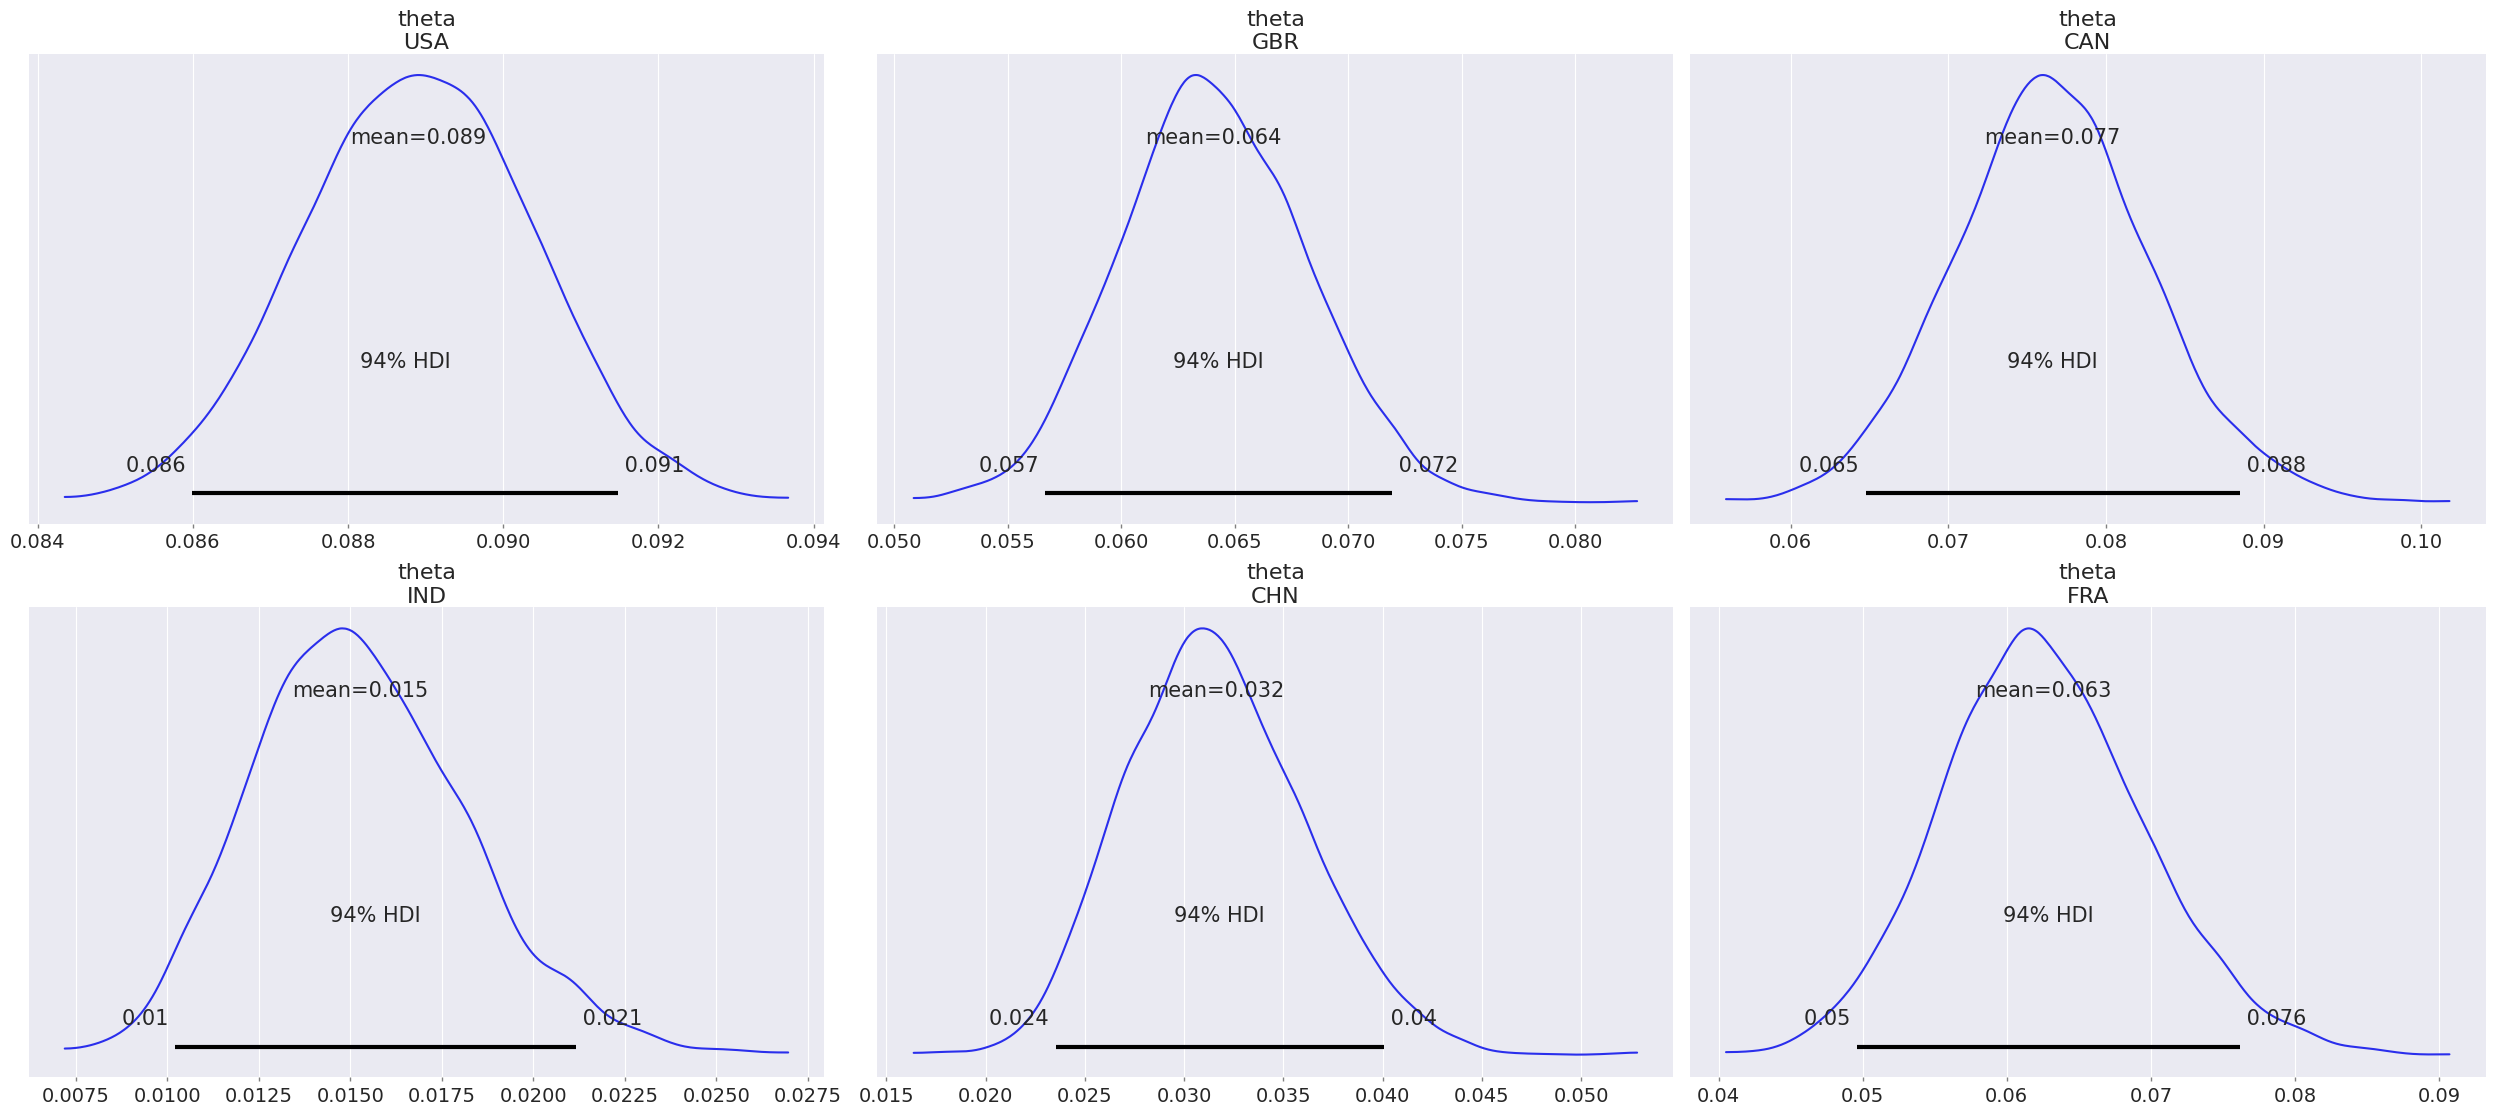

In [31]:
az.plot_posterior(
    idata_unpooled,
    var_names=["theta"],
    coords={"country": country_names[:6]},
    hdi_prob=0.94
)

plt.show()

/tmp/ipykernel_590/2239079766.py:138: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


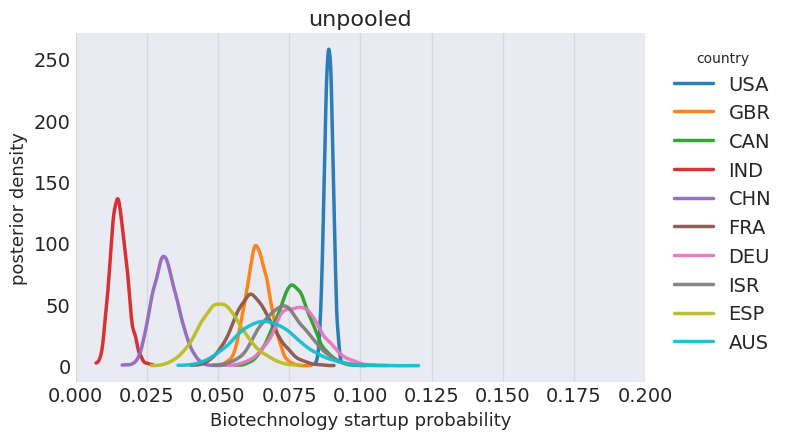

In [69]:
# Unpooled model: separate theta for each country
plot_group_theta_densities(
    idata=idata_unpooled,
    group_names=country_names,
    dim_name="country",
    title="unpooled",
    max_groups=10,
    xlim=(0, 0.20)
)

# 3. Hierarchical model

The hierarchical model estimates a separate Biotechnology startup probability for each country,
but the country probabilities are connected through shared hyperparameters.

This creates information sharing between countries.

In [33]:
coords = {"country": country_names}

with pm.Model(coords=coords) as hierarchical_model:

    # hyperpriors
    mu_theta = pm.Beta(
        "mu_theta", alpha=omega_alpha, beta=omega_beta)

    nu_theta = pm.HalfNormal("nu_theta", sigma=10)

    # country-level prior
    theta = pm.Beta("theta", mu=mu_theta, nu=nu_theta, dims="country")

    # likelihood
    z = pm.Binomial("z", n=n_startups, p=theta, observed=n_biotech, dims="country")

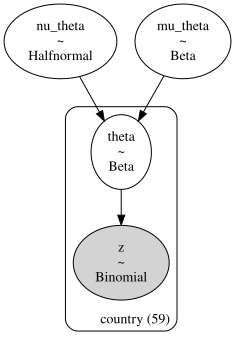

In [34]:
pm.model_to_graphviz(hierarchical_model)

### Prior predictive check

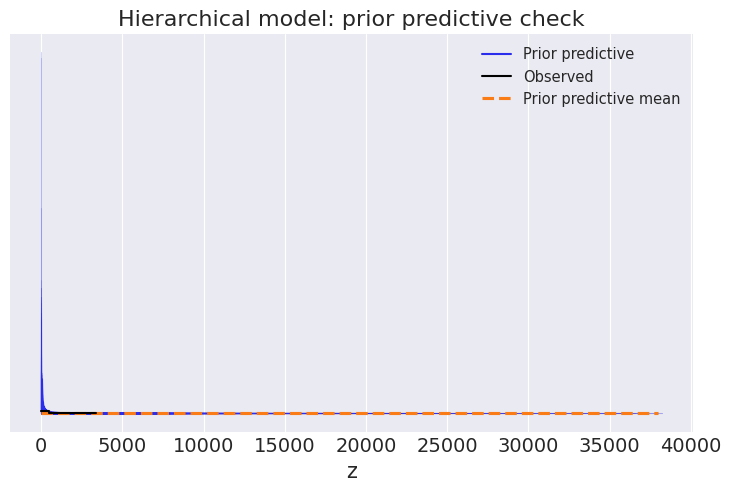

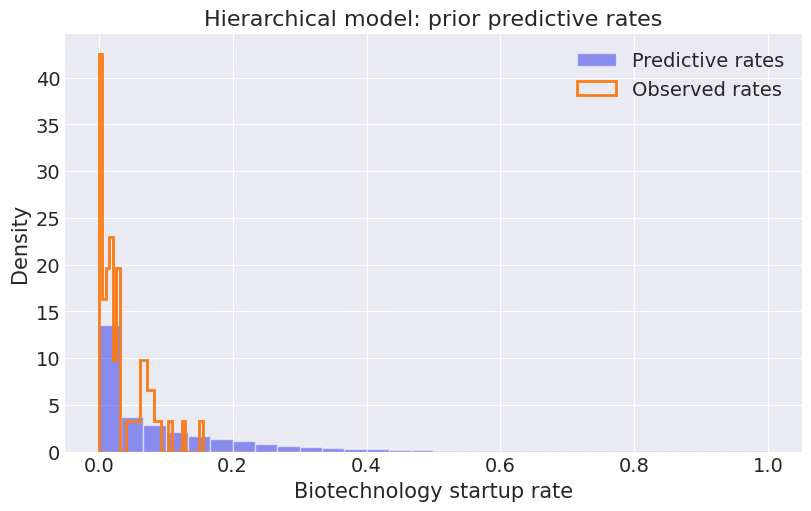

In [35]:
# Prior predictive check

with hierarchical_model:
    idata_hierarchical_prior = pm.sample_prior_predictive(
        samples=1000,
        random_seed=random_seed
    )

az.plot_ppc(
    idata_hierarchical_prior,
    group="prior",
    observed=True
)

plt.title("Hierarchical model: prior predictive check")
plt.show()

plot_predictive_rates(
    idata=idata_hierarchical_prior,
    group_name="prior_predictive",
    n_trials=n_startups,
    observed_rates=observed_rate,
    title="Hierarchical model: prior predictive rates"
)

### Sample and diagnostics

In [36]:
with hierarchical_model:
  idata_hierarchical = pm.sample(
        draws=1000,
        chains=4,
        random_seed=random_seed,
        target_accept=0.95
    )

idata_hierarchical


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [37]:
# hyperpriors
az.summary(
    idata_hierarchical,
    kind="diagnostics",
    var_names=["mu_theta", "nu_theta"]
)

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_theta,0.000,0.00,3128.0,2919.0,1.0
nu_theta,0.109,0.07,1966.0,2475.0,1.0


In [38]:
# country level prior
az.summary(
    idata_hierarchical,
    kind="diagnostics",
    var_names=["theta"],
    coords={"country": country_names[:6]}
)


,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta[USA],0.0,0.0,4877.0,2618.0,1.0
theta[GBR],0.0,0.0,5487.0,2709.0,1.0
theta[CAN],0.0,0.0,5016.0,2816.0,1.0
theta[IND],0.0,0.0,4834.0,2895.0,1.0
theta[CHN],0.0,0.0,5199.0,2692.0,1.0
theta[FRA],0.0,0.0,4369.0,3067.0,1.0


/tmp/ipykernel_590/1906733670.py:7: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.6)


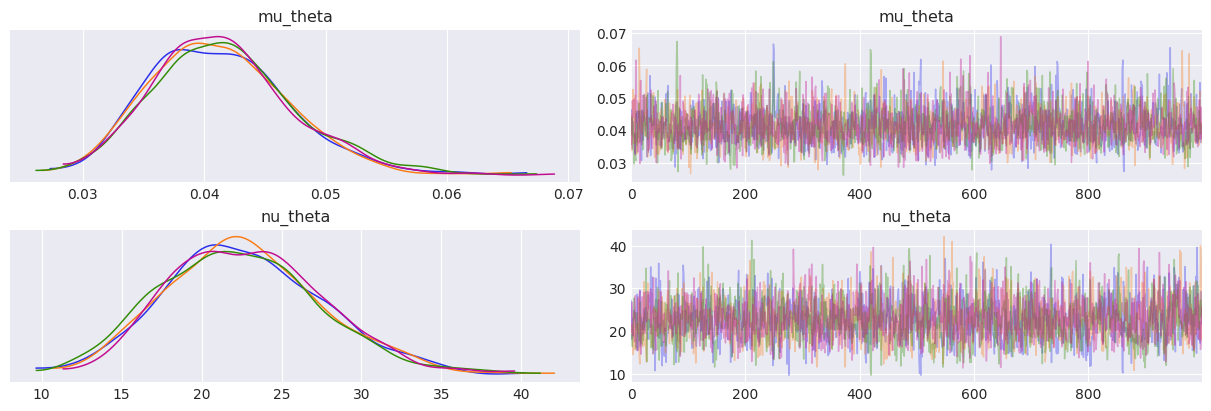

In [39]:
az.plot_trace(
    idata_hierarchical,
    var_names=["mu_theta", "nu_theta"],
    compact=False
)

plt.subplots_adjust(hspace=0.6)
plt.show()

/tmp/ipykernel_590/1453547117.py:8: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.8)


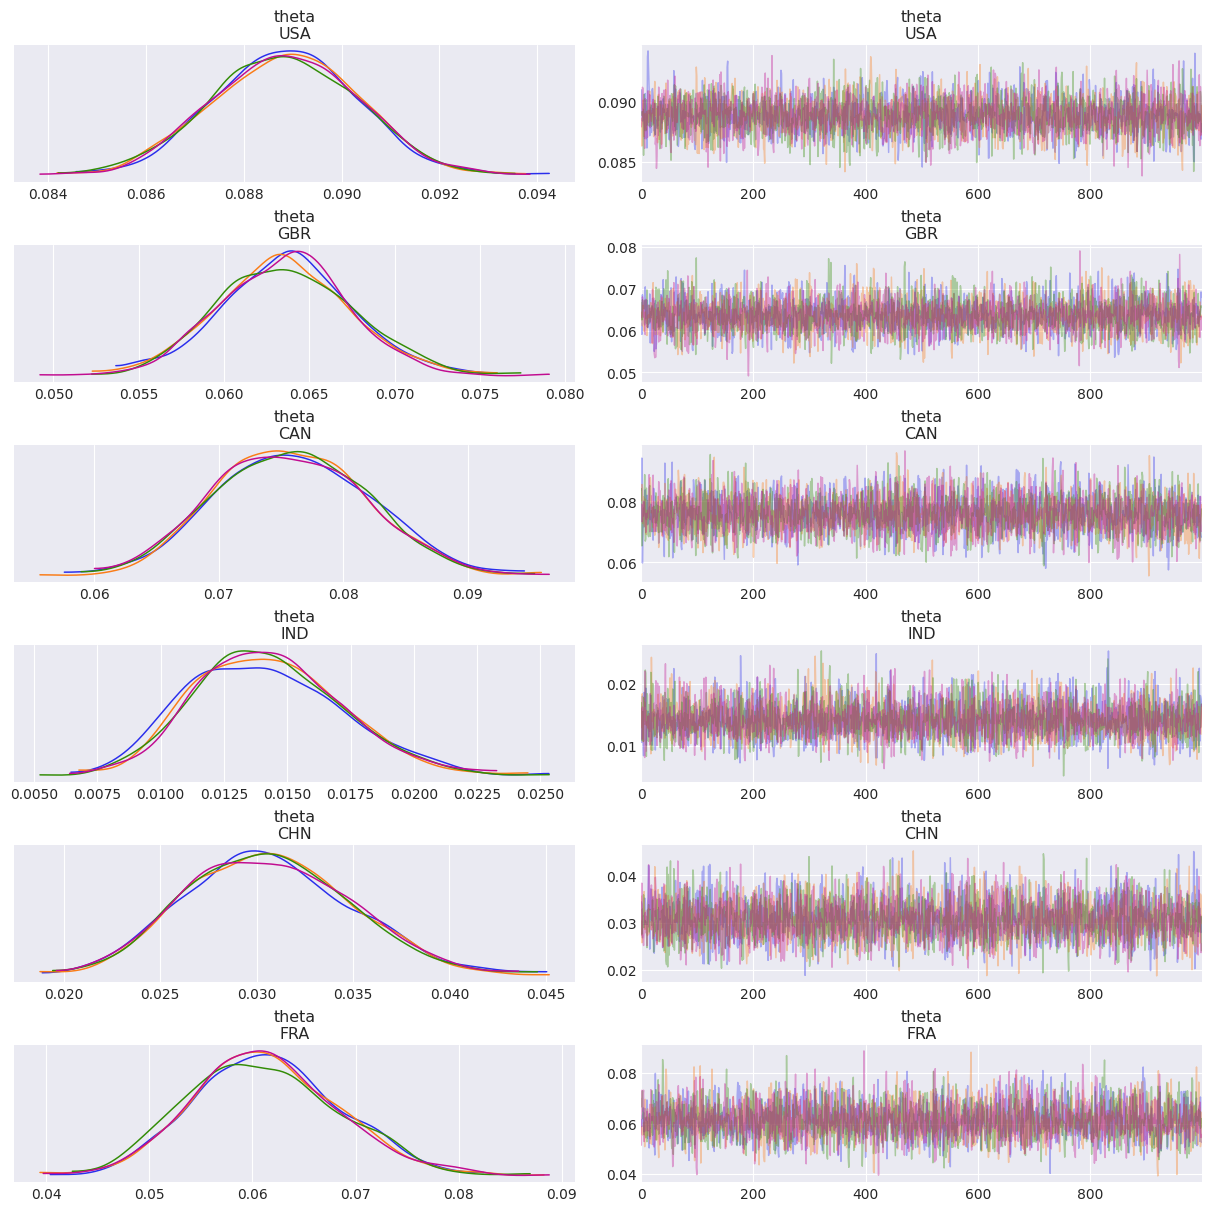

In [40]:
az.plot_trace(
    idata_hierarchical,
    var_names=["theta"],
    coords={"country": country_names[:6]},
    compact=False
)

plt.subplots_adjust(hspace=0.8)
plt.show()

In [41]:
hierarchical_divergences = idata_hierarchical.sample_stats["diverging"].sum().values
print(f"Number of divergences: {hierarchical_divergences}")

Number of divergences: 0


### Funnel / divergences check

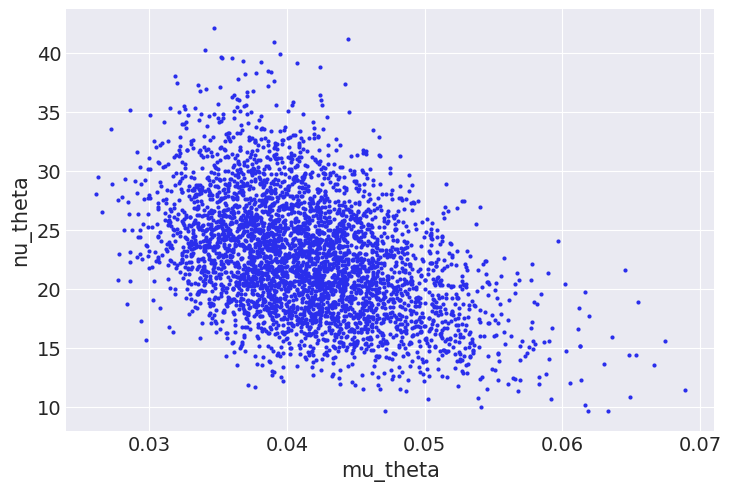

In [42]:
az.plot_pair(
    idata_hierarchical,
    var_names=["mu_theta", "nu_theta"],
    kind="scatter",
    divergences=True
)

plt.show()

### Posterior predictive check

Output()

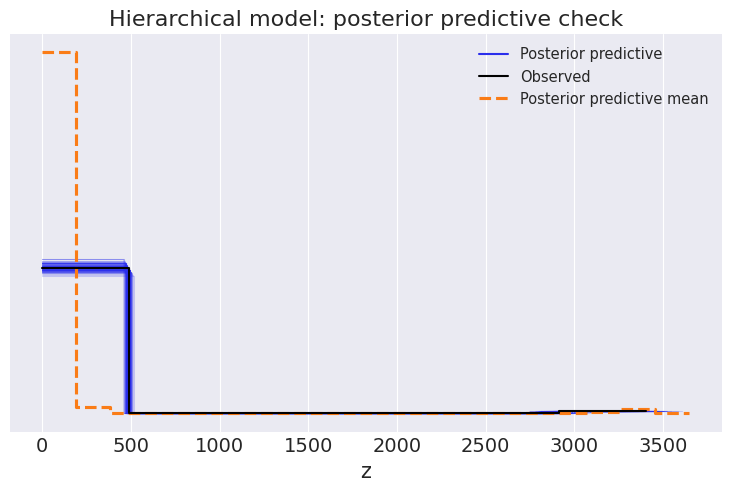

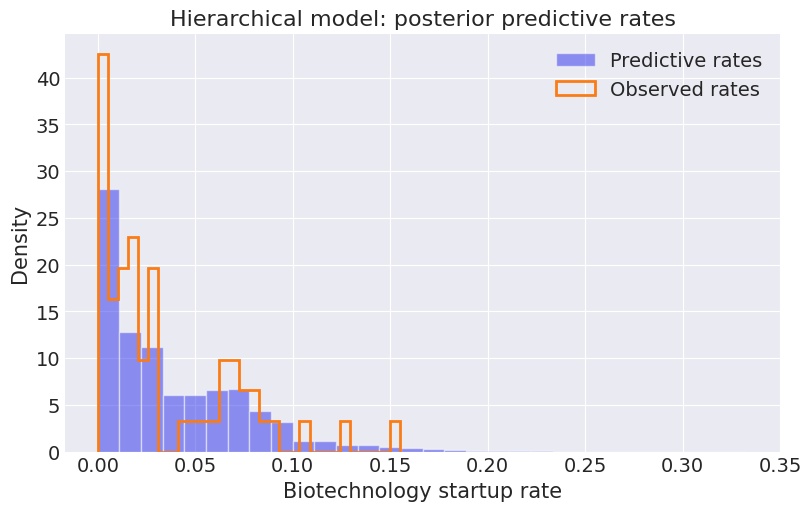

In [43]:
# Posterior predictive check

with hierarchical_model:
    idata_hierarchical = pm.sample_posterior_predictive(
        idata_hierarchical,
        var_names=["z"],
        random_seed=random_seed,
        extend_inferencedata=True
    )

az.plot_ppc(
    idata_hierarchical,
    group="posterior",
    observed=True,
    num_pp_samples=100
)

plt.title("Hierarchical model: posterior predictive check")
plt.show()

plot_predictive_rates(
    idata=idata_hierarchical,
    group_name="posterior_predictive",
    n_trials=n_startups,
    observed_rates=observed_rate,
    title="Hierarchical model: posterior predictive rates"
)

### Posterior

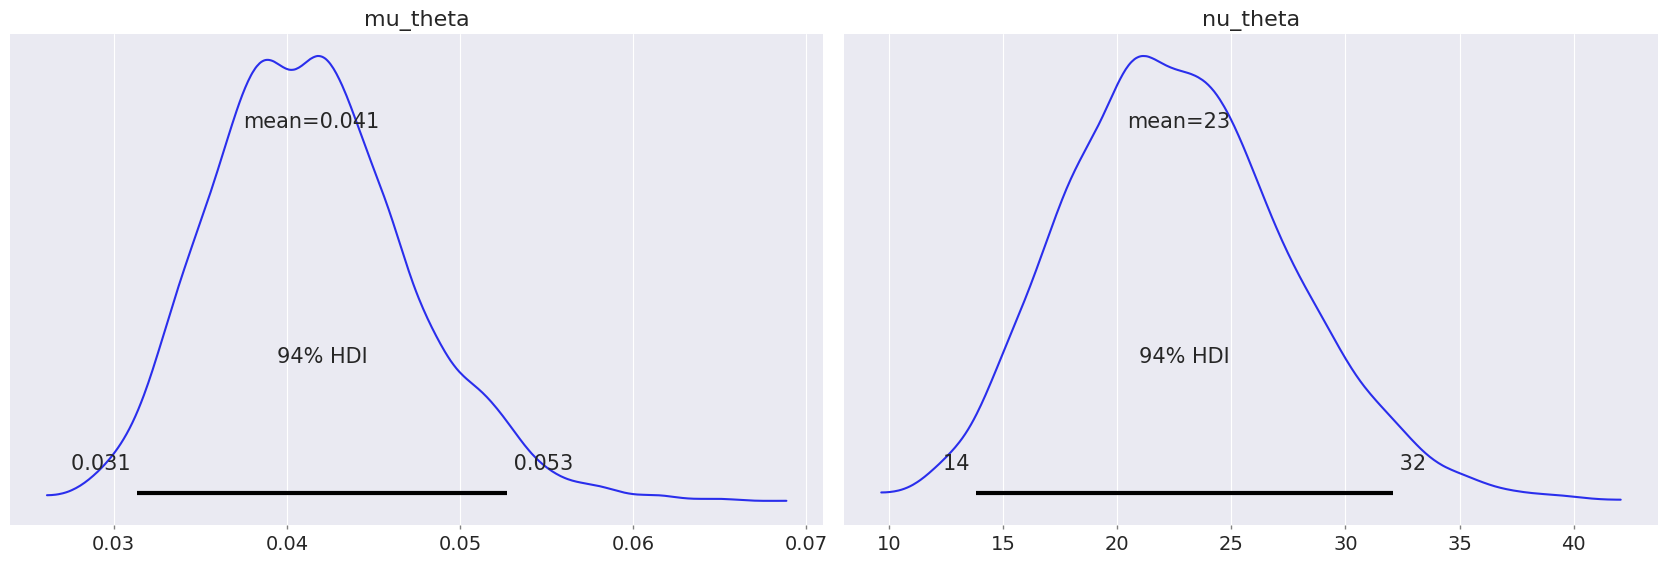

In [44]:
az.plot_posterior(
    idata_hierarchical,
    var_names=["mu_theta", "nu_theta"],
    hdi_prob=0.94
)

plt.show()

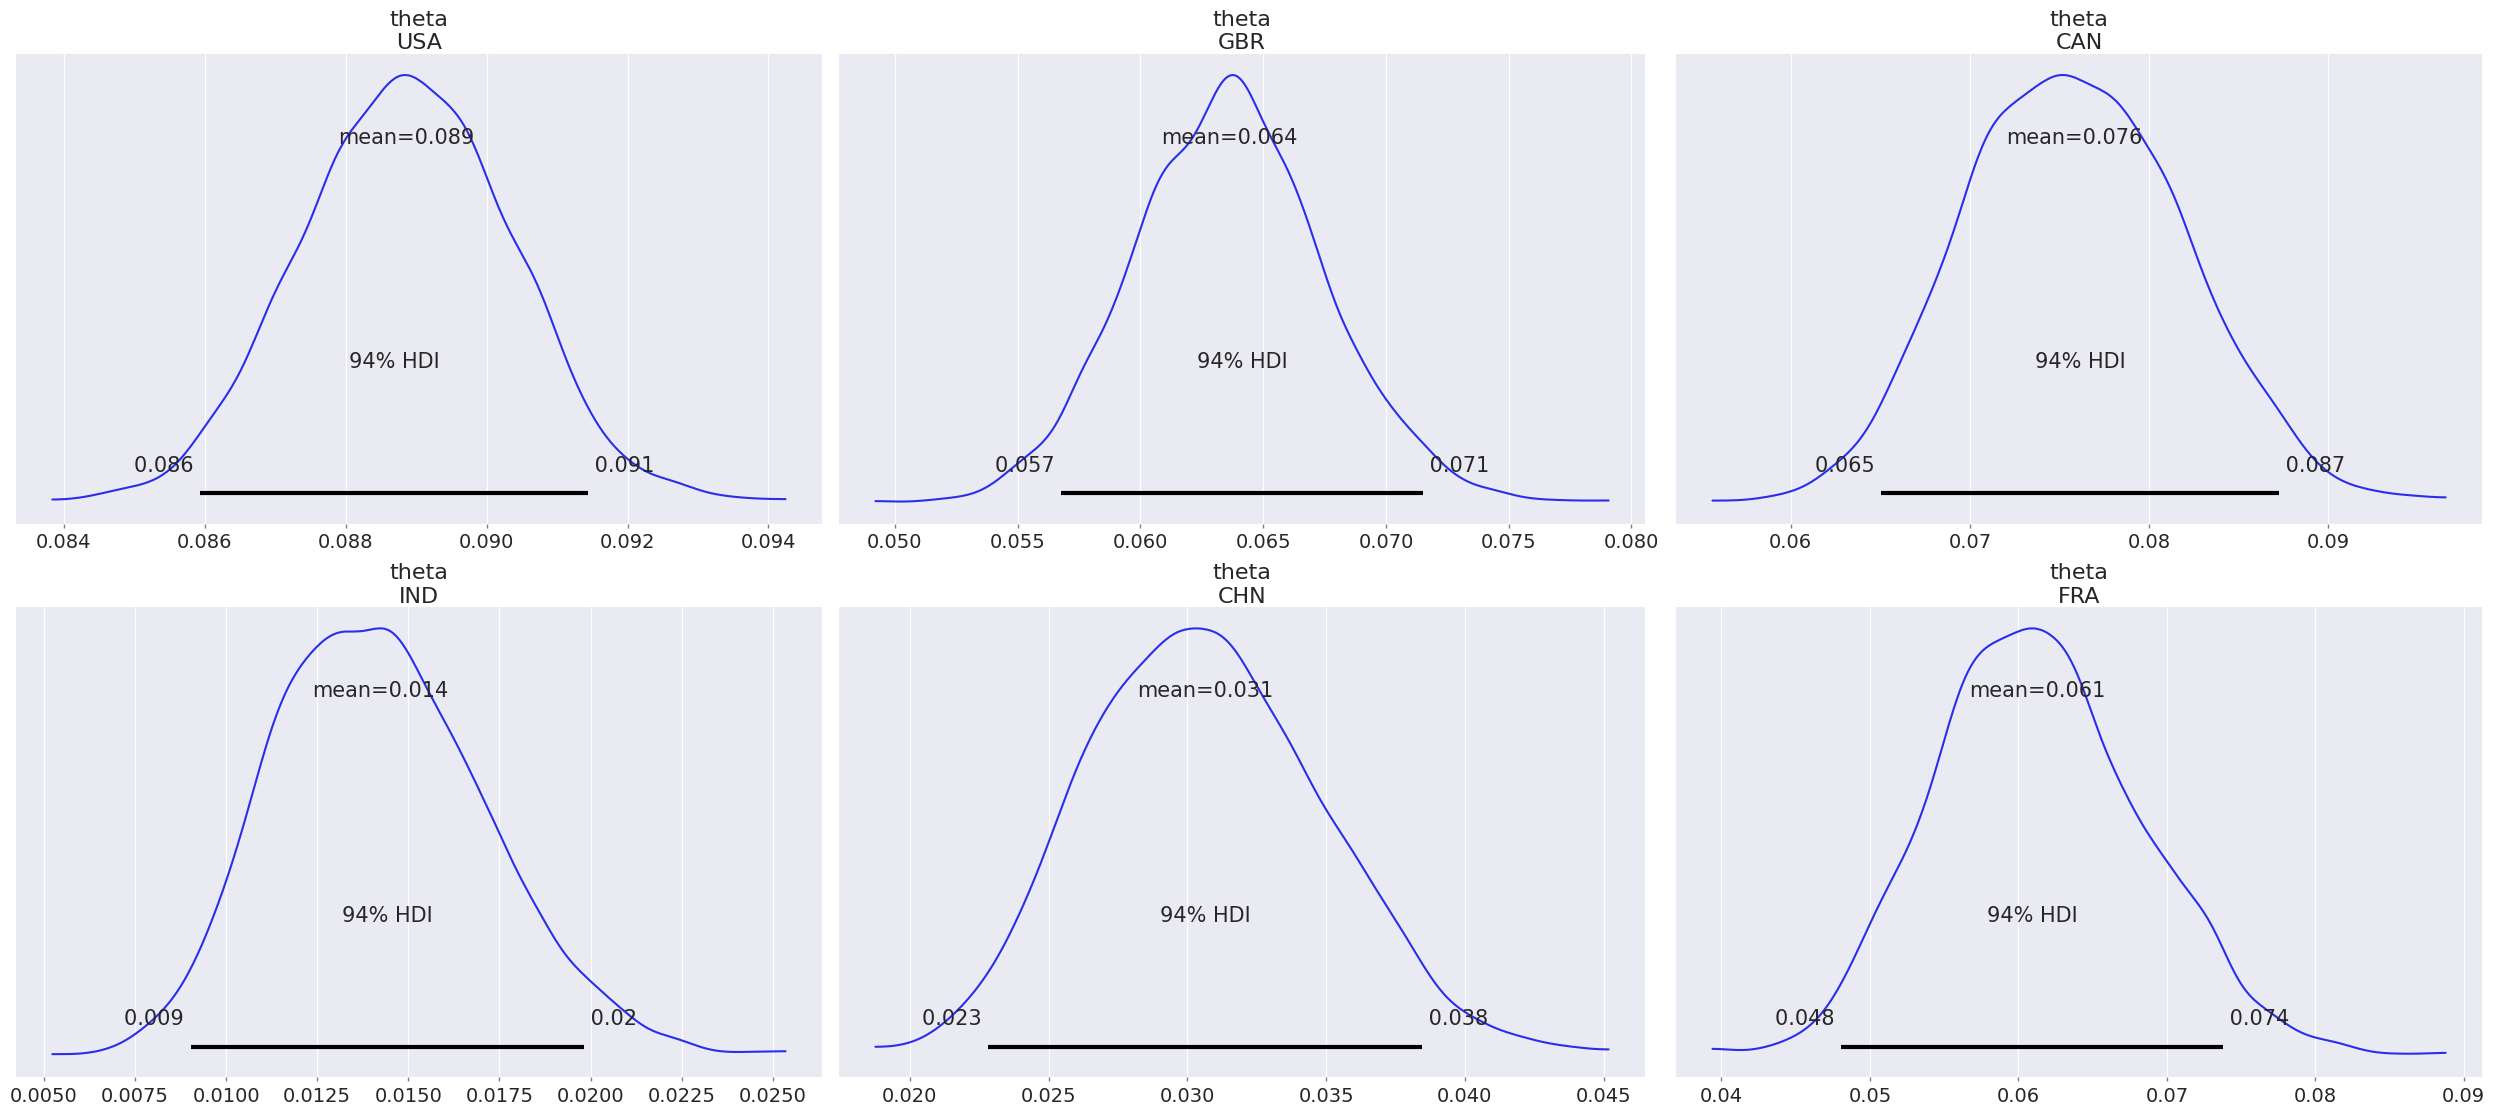

In [45]:
az.plot_posterior(
    idata_hierarchical,
    var_names=["theta"],
    coords={"country": country_names[:6]},
    hdi_prob=0.94
)

plt.show()

/tmp/ipykernel_590/2239079766.py:138: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


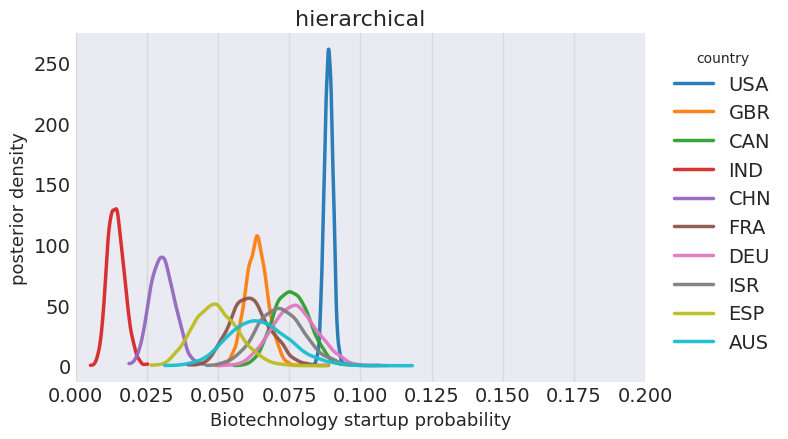

In [70]:
# Hierarchical model: separate theta for each country,
# but with information sharing through mu_theta and nu_theta
plot_group_theta_densities(
    idata=idata_hierarchical,
    group_names=country_names,
    dim_name="country",
    title="hierarchical",
    max_groups=10,
    xlim=(0, 0.20)
)

### Shrinkage plot

In [47]:
# Posterior mean for each country

posterior_theta = idata_hierarchical.posterior["theta"]
posterior_theta_mean = posterior_theta.mean(dim=("chain", "draw")).values

shrinkage_df = pd.DataFrame({
    "country": country_names,
    "n_startups": n_startups,
    "n_biotech": n_biotech,
    "observed_rate": observed_rate,
    "posterior_mean": posterior_theta_mean
})

shrinkage_df = shrinkage_df.sort_values("n_startups", ascending=False)

shrinkage_df.head()

,country,n_startups,n_biotech,observed_rate,posterior_mean
0,USA,37601,3342,0.088881,0.088856
1,GBR,3688,235,0.063720,0.063604
2,CAN,1925,147,0.076364,0.075834
3,IND,1596,22,0.013784,0.014218
4,CHN,1544,47,0.030440,0.030637


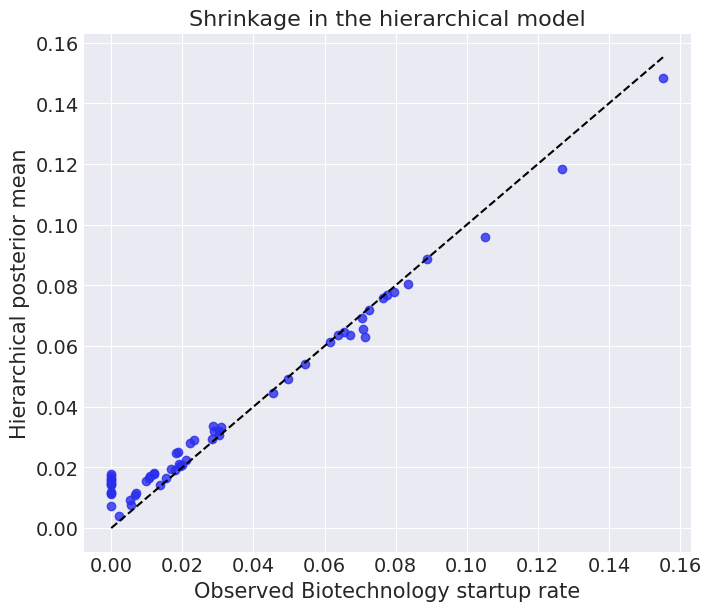

In [48]:
plt.figure(figsize=(7, 6))

plt.scatter(
    shrinkage_df["observed_rate"],
    shrinkage_df["posterior_mean"],
    alpha=0.8
)

max_rate = max(
    shrinkage_df["observed_rate"].max(),
    shrinkage_df["posterior_mean"].max()
)

plt.plot(
    [0, max_rate],
    [0, max_rate],
    linestyle="--",
    color="black"
)

plt.xlabel("Observed Biotechnology startup rate")
plt.ylabel("Hierarchical posterior mean")
plt.title("Shrinkage in the hierarchical model")

plt.show()

In [87]:
def plot_hdi_width_shrinkage(
    idata_unpooled,
    idata_hierarchical,
    group_names,
    group_dim="country",
    group_sizes=None,
    hdi_prob=0.94,
    selected_groups=None,
    max_groups=15,
    sort_by="shrinkage",
    figsize=(8, 6),
):
    """
    Plot HDI width shrinkage from the unpooled model to the hierarchical model.

    Shrinkage here means:
        HDI width in unpooled model - HDI width in hierarchical model

    Parameters
    ----------
    idata_unpooled : arviz.InferenceData
        Posterior from the unpooled model.

    idata_hierarchical : arviz.InferenceData
        Posterior from the hierarchical model.

    group_names : array-like
        Names of the groups, for example country_names.

    group_dim : str
        Dimension name of theta, usually "country".

    group_sizes : array-like or None
        Number of observations per group, for example n_startups.
        If provided, it is added to the output table.

    hdi_prob : float
        HDI probability. ArviZ default is usually 0.94.

    selected_groups : list or None
        Specific groups to show, for example ["USA", "GBR", "FRA"].

    max_groups : int or None
        Maximum number of groups to show.
        Ignored if selected_groups is provided.

    sort_by : str
        Options:
        - "shrinkage": largest HDI width shrinkage first
        - "group_size": smallest groups first
        - "hierarchical_width": widest hierarchical HDI first
        - "name": alphabetical order

    figsize : tuple
        Figure size.
    """

    group_names = np.asarray(group_names)

    if group_sizes is not None:
        group_sizes = np.asarray(group_sizes)

    def get_hdi_width(idata, var_name="theta"):
        theta = idata.posterior[var_name]

        hdi = az.hdi(theta, hdi_prob=hdi_prob)

        # ArviZ usually returns a Dataset when the input has a variable name
        if isinstance(hdi, xr.Dataset):
            hdi_theta = hdi[var_name]
        else:
            hdi_theta = hdi

        hdi_labels = list(hdi_theta["hdi"].values)

        lower_label = "lower" if "lower" in hdi_labels else hdi_labels[0]
        upper_label = "higher" if "higher" in hdi_labels else hdi_labels[-1]

        lower = hdi_theta.sel(hdi=lower_label)
        upper = hdi_theta.sel(hdi=upper_label)

        width = upper - lower

        return width.sel({group_dim: group_names}).to_numpy()

    unpooled_width = get_hdi_width(idata_unpooled)
    hierarchical_width = get_hdi_width(idata_hierarchical)

    shrinkage = unpooled_width - hierarchical_width
    shrinkage_percent = 100 * shrinkage / unpooled_width

    shrinkage_df = pd.DataFrame({
        group_dim: group_names,
        "unpooled_hdi_width": unpooled_width,
        "hierarchical_hdi_width": hierarchical_width,
        "hdi_width_shrinkage": shrinkage,
        "hdi_width_shrinkage_percent": shrinkage_percent,
    })

    if group_sizes is not None:
        shrinkage_df["group_size"] = group_sizes

    # Select groups
    if selected_groups is not None:
        shrinkage_df = shrinkage_df[
            shrinkage_df[group_dim].isin(selected_groups)
        ].copy()
    else:
        if sort_by == "shrinkage":
            shrinkage_df = shrinkage_df.sort_values(
                "hdi_width_shrinkage",
                ascending=False
            )
        elif sort_by == "group_size" and group_sizes is not None:
            shrinkage_df = shrinkage_df.sort_values(
                "group_size",
                ascending=True
            )
        elif sort_by == "hierarchical_width":
            shrinkage_df = shrinkage_df.sort_values(
                "hierarchical_hdi_width",
                ascending=False
            )
        elif sort_by == "name":
            shrinkage_df = shrinkage_df.sort_values(group_dim)

        if max_groups is not None:
            shrinkage_df = shrinkage_df.head(max_groups)

    # Reverse order so largest/first appears at top of plot
    plot_df = shrinkage_df.iloc[::-1].reset_index(drop=True)

    y_pos = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=figsize)

    # Lines from unpooled width to hierarchical width
    ax.hlines(
        y=y_pos,
        xmin=plot_df["hierarchical_hdi_width"],
        xmax=plot_df["unpooled_hdi_width"],
        color="0.75",
        linewidth=2,
        zorder=1,
    )

    ax.scatter(
        plot_df["unpooled_hdi_width"],
        y_pos,
        label="unpooled HDI width",
        s=55,
        zorder=2,
    )

    ax.scatter(
        plot_df["hierarchical_hdi_width"],
        y_pos,
        label="hierarchical HDI width",
        s=55,
        zorder=3,
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df[group_dim])

    ax.set_xlabel(f"{int(hdi_prob * 100)}% HDI width of $\\theta$")
    ax.set_ylabel(group_dim)
    ax.set_title("HDI width shrinkage in the hierarchical model")

    ax.grid(axis="x", color="0.85", linewidth=1)
    ax.grid(axis="y", visible=False)

    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

    return shrinkage_df.reset_index(drop=True)

/tmp/ipykernel_590/846630994.py:175: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


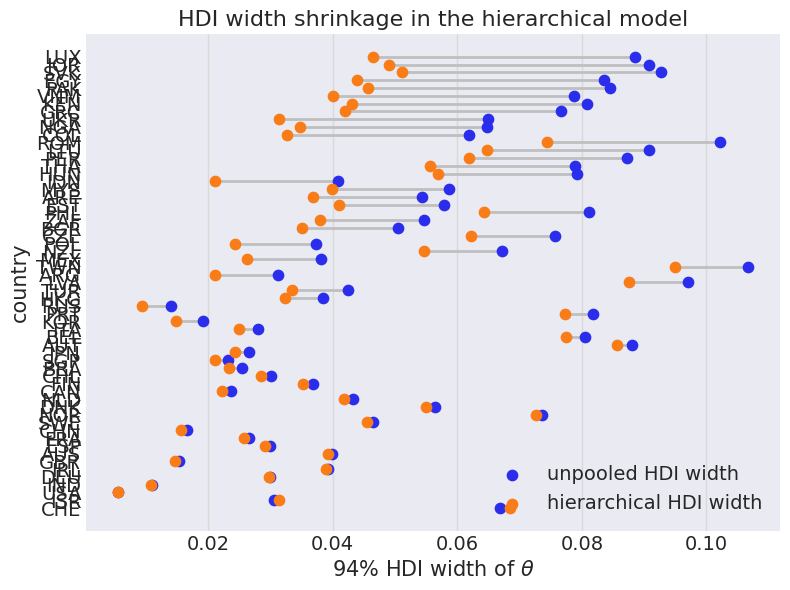

In [92]:
hdi_shrinkage_df = plot_hdi_width_shrinkage(
    idata_unpooled=idata_unpooled,
    idata_hierarchical=idata_hierarchical,
    group_names=country_names,
    group_dim="country",
    group_sizes=n_startups,
    hdi_prob=0.94,
    max_groups=None,
    sort_by="shrinkage",
)

/tmp/ipykernel_590/846630994.py:175: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


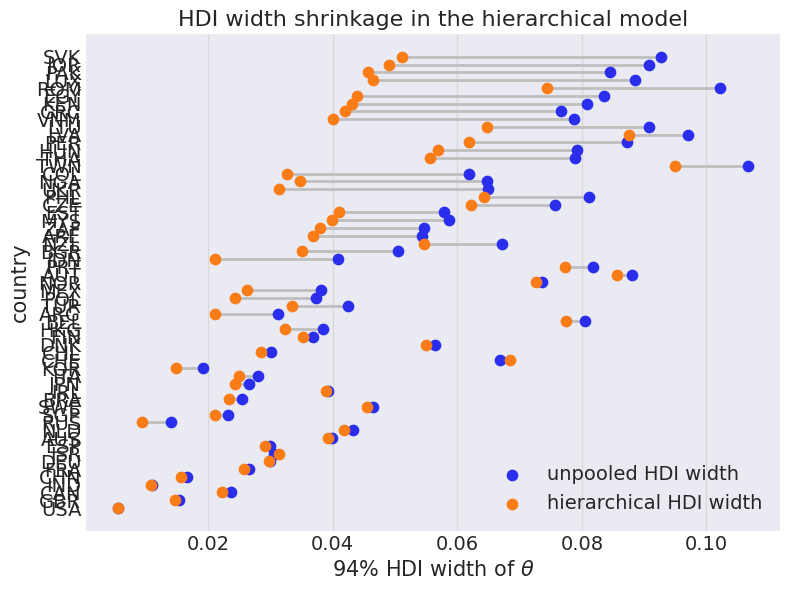

In [94]:
hdi_shrinkage_df = plot_hdi_width_shrinkage(
    idata_unpooled=idata_unpooled,
    idata_hierarchical=idata_hierarchical,
    group_names=country_names,
    group_dim="country",
    group_sizes=n_startups,
    hdi_prob=0.94,
    max_groups=None,
    sort_by="group_size",
)

# 4. Multi-level model

The multi-level model adds another level of group structure.

Here:
- Cities are the lower-level groups
- Countries are the higher-level groups

Each city has its own Biotechnology startup probability.

Cities from the same country are connected through country-level hyperparameters.

In [49]:
required_columns = ["country_code", "city", "biotech"]

missing_columns = [col for col in required_columns if col not in df.columns]

if len(missing_columns) > 0:
    raise ValueError(f"Missing required columns: {missing_columns}")

df_city = df.dropna(subset=["country_code", "city"]).copy()

df_city["country_code"] = df_city["country_code"].astype(str).str.strip()
df_city["city"] = df_city["city"].astype(str).str.strip()

city_data = (
    df_city
    .groupby(["country_code", "city"])
    .agg(
        n_startups=("biotech", "size"),
        n_biotech=("biotech", "sum")
    )
    .reset_index()
)

city_data["observed_biotech_rate"] = (
    city_data["n_biotech"] / city_data["n_startups"]
)

city_data = city_data.sort_values("n_startups", ascending=False).reset_index(drop=True)

city_data.head(10)

min_startups_per_city = 100

city_data_filtered = (
    city_data[city_data["n_startups"] >= min_startups_per_city]
    .copy()
    .reset_index(drop=True)
)

print(f"Number of cities before filtering: {len(city_data)}")
print(f"Number of cities after filtering: {len(city_data_filtered)}")

city_data_filtered.head()


Number of cities before filtering: 5293
Number of cities after filtering: 89


,country_code,city,n_startups,n_biotech,observed_biotech_rate
0,USA,San Francisco,3526,87,0.024674
1,USA,New York,3163,88,0.027822
2,GBR,London,1907,39,0.020451
3,USA,Austin,774,36,0.046512
4,USA,Palo Alto,769,38,0.049415


In [50]:
# City names alone may not be unique.
# For example, the same city name can appear in different countries.
# Therefore, we create a unique city label for the model coordinate.

city_data_filtered["city_label"] = (
    city_data_filtered["country_code"].astype(str)
    + " - "
    + city_data_filtered["city"].astype(str)
)

city_names = city_data_filtered["city_label"].to_numpy()
city_display_names = city_data_filtered["city"].to_numpy()
city_country = city_data_filtered["country_code"].to_numpy()

city_n_startups = city_data_filtered["n_startups"].to_numpy()
city_n_biotech = city_data_filtered["n_biotech"].to_numpy()
city_observed_rate = city_data_filtered["observed_biotech_rate"].to_numpy()

country_idx, country_codes_multilevel = pd.factorize(city_country)

coords_multilevel = {
    "country": country_codes_multilevel,
    "city": city_names
}

print(f"Number of countries: {len(country_codes_multilevel)}")
print(f"Number of cities: {len(city_names)}")
print(f"Are city coordinate labels unique? {pd.Index(city_names).is_unique}")

Number of countries: 25
Number of cities: 89
Are city coordinate labels unique? True


### Multi-level model

In the Beta distribution, nu controls how concentrated the distribution is around mu. Since nu is a concentration parameter, it must be positive. We use a Gamma prior for nu because it only generates positive values and is therefore stable for prior predictive sampling.

In [51]:
with pm.Model(coords=coords_multilevel) as multilevel_model:
    # data index:
    # for each city, this tells us which country it belongs to
    c_i = pm.Data("c_i", country_idx, dims="city")

    # hyperpriors
    mu_global = pm.Beta("mu_global", alpha=omega_alpha, beta=omega_beta)

    nu_global = pm.Gamma("nu_global", mu=10, sigma=5)

    # country-level hyperparameters
    mu_country = pm.Beta("mu_country", mu=mu_global, nu=nu_global, dims="country")

    nu_country = pm.Gamma("nu_country", mu=10, sigma=5, dims="country")

    # city-level prior
    theta = pm.Beta("theta", mu=mu_country[c_i], nu=nu_country[c_i], dims="city")

    # likelihood
    z = pm.Binomial("z", n=city_n_startups, p=theta, observed=city_n_biotech, dims="city")

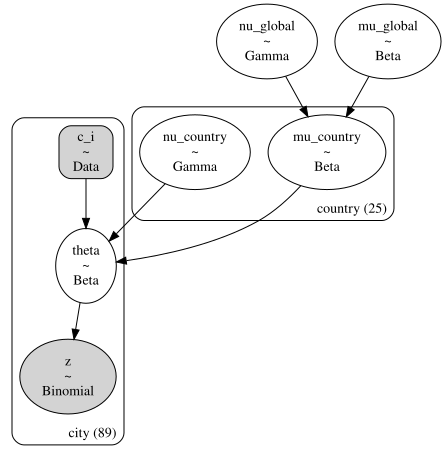

In [52]:
pm.model_to_graphviz(multilevel_model)

### Prior predictive check

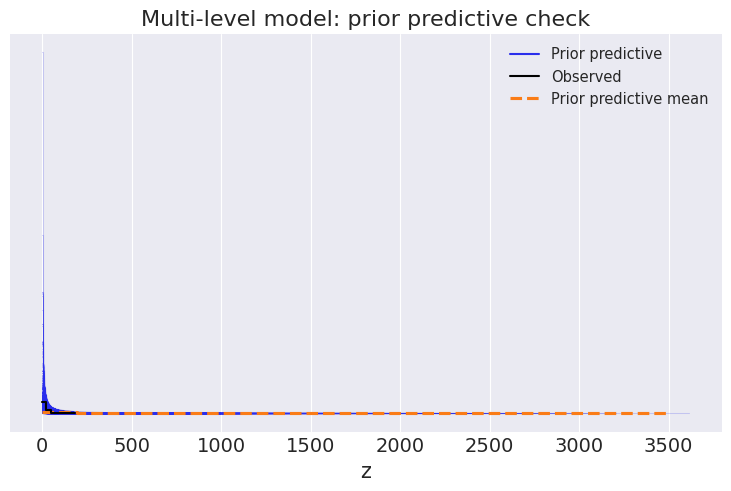

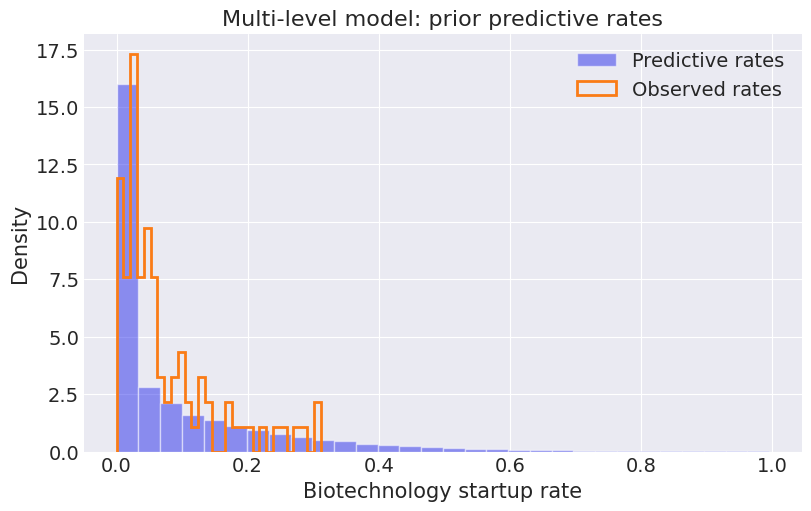

In [53]:
with multilevel_model:
    idata_multilevel_prior = pm.sample_prior_predictive(
        samples=1000,
        random_seed=random_seed
    )

az.plot_ppc(
    idata_multilevel_prior,
    group="prior",
    observed=True
)

plt.title("Multi-level model: prior predictive check")
plt.show()

plot_predictive_rates(
    idata=idata_multilevel_prior,
    group_name="prior_predictive",
    n_trials=city_n_startups,
    observed_rates=city_observed_rate,
    title="Multi-level model: prior predictive rates"
)

### Sample and diagnostics

In [54]:
with multilevel_model:
    idata_multilevel = pm.sample(
        draws=1000,
        chains=4,
        random_seed=random_seed,
        target_accept=0.95
    )

idata_multilevel


Output()

ERROR:pymc.stats.convergence:There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [55]:
# Global hyperparameters
az.summary(
    idata_multilevel,
    kind="diagnostics",
    var_names=["mu_global", "nu_global"]
)


,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_global,0.000,0.000,1900.0,2256.0,1.0
nu_global,0.154,0.132,1962.0,2304.0,1.0


In [56]:
# Country-level hyperparameters
selected_countries = country_codes_multilevel[:6]

az.summary(
    idata_multilevel,
    kind="diagnostics",
    var_names=["mu_country", "nu_country"],
    coords={"country": selected_countries}
)

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_country[USA],0.000,0.000,3200.0,2397.0,1.0
mu_country[GBR],0.001,0.001,3590.0,2631.0,1.0
mu_country[FRA],0.001,0.001,3558.0,2119.0,1.0
mu_country[CHN],0.000,0.001,3112.0,2479.0,1.0
mu_country[CAN],0.001,0.001,3480.0,2771.0,1.0
mu_country[SGP],0.001,0.001,2752.0,1798.0,1.0
nu_country[USA],0.055,0.050,2990.0,2520.0,1.0
nu_country[GBR],0.058,0.063,3896.0,2222.0,1.0
nu_country[FRA],0.071,0.093,4731.0,2575.0,1.0
nu_country[CHN],0.086,0.095,3506.0,2262.0,1.0


In [57]:
# City-level parameters
selected_cities = city_names[:6]

az.summary(
    idata_multilevel,
    kind="diagnostics",
    var_names=["theta"],
    coords={"city": selected_cities}
)


,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta[USA - San Francisco],0.0,0.0,4993.0,2525.0,1.0
theta[USA - New York],0.0,0.0,4356.0,2543.0,1.0
theta[GBR - London],0.0,0.0,4506.0,2497.0,1.0
theta[USA - Austin],0.0,0.0,4329.0,2267.0,1.0
theta[USA - Palo Alto],0.0,0.0,3123.0,1798.0,1.0
theta[USA - Los Angeles],0.0,0.0,5262.0,2471.0,1.0


/tmp/ipykernel_590/2727184545.py:8: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.6)


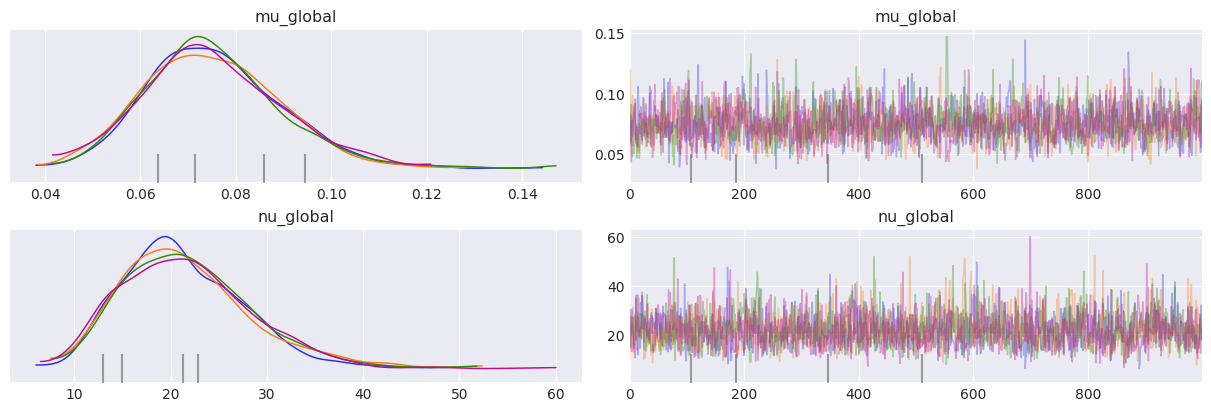

In [58]:
# Global hyperparameters
az.plot_trace(
    idata_multilevel,
    var_names=["mu_global", "nu_global"],
    compact=False
)

plt.subplots_adjust(hspace=0.6)
plt.show()


/tmp/ipykernel_590/2278301272.py:9: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.8)


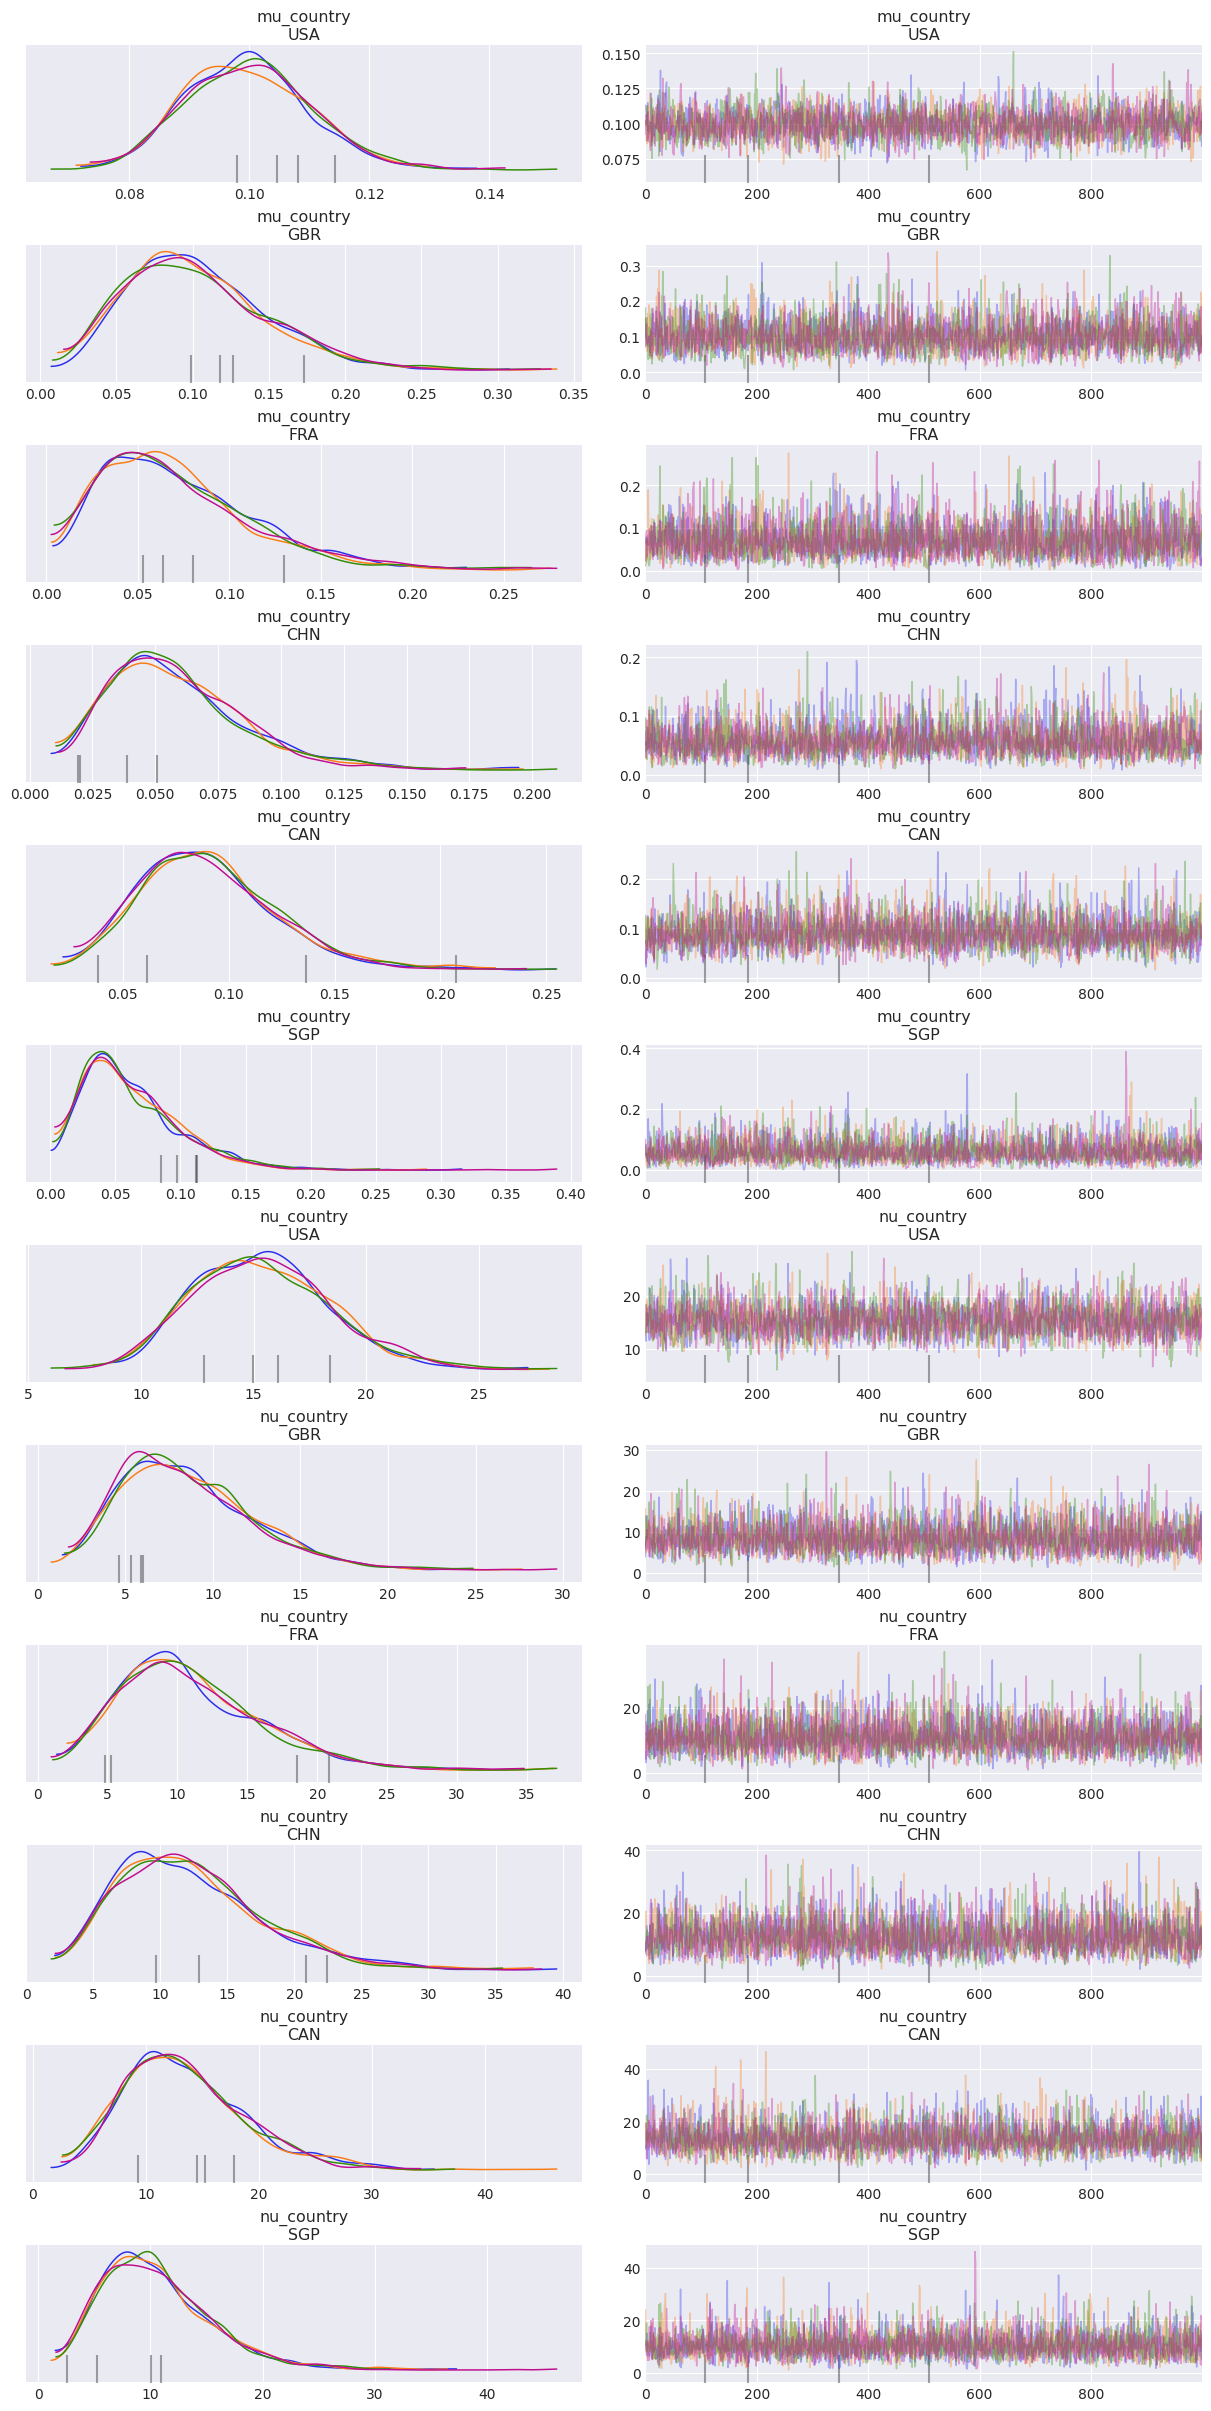

In [59]:
# Country-level hyperparameters
az.plot_trace(
    idata_multilevel,
    var_names=["mu_country", "nu_country"],
    coords={"country": selected_countries},
    compact=False
)

plt.subplots_adjust(hspace=0.8)
plt.show()


/tmp/ipykernel_590/323800315.py:9: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.8)


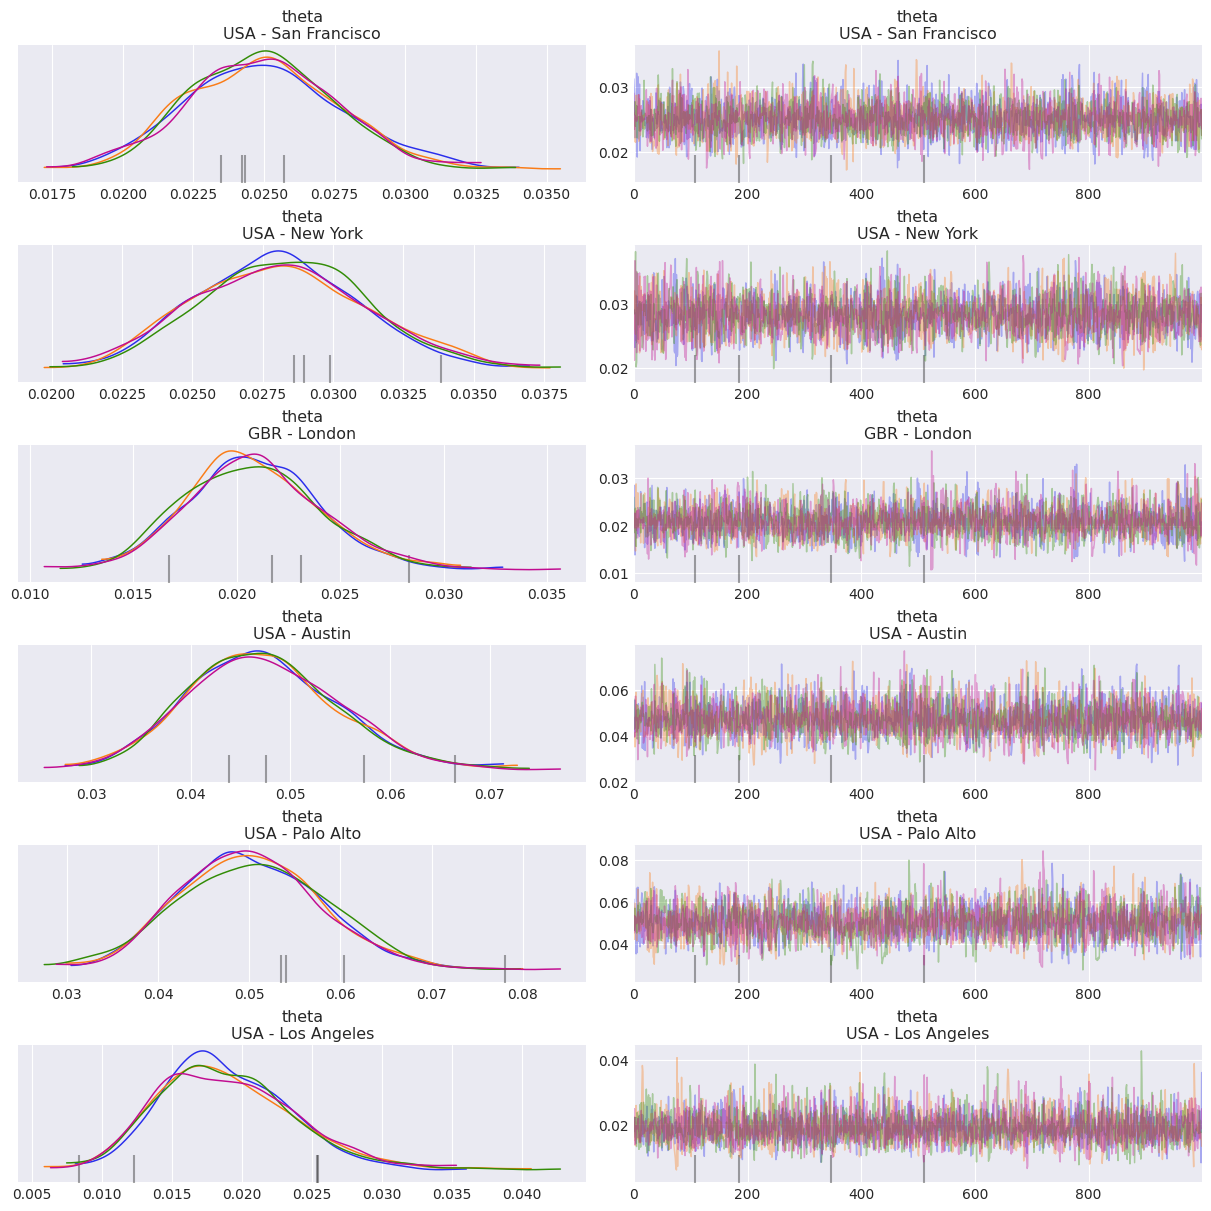

Number of divergences: 4


In [60]:
# City-level parameters
az.plot_trace(
    idata_multilevel,
    var_names=["theta"],
    coords={"city": selected_cities},
    compact=False
)

plt.subplots_adjust(hspace=0.8)
plt.show()

multilevel_divergences = idata_multilevel.sample_stats["diverging"].sum().values
print(f"Number of divergences: {multilevel_divergences}")

### Funnel / divergences check

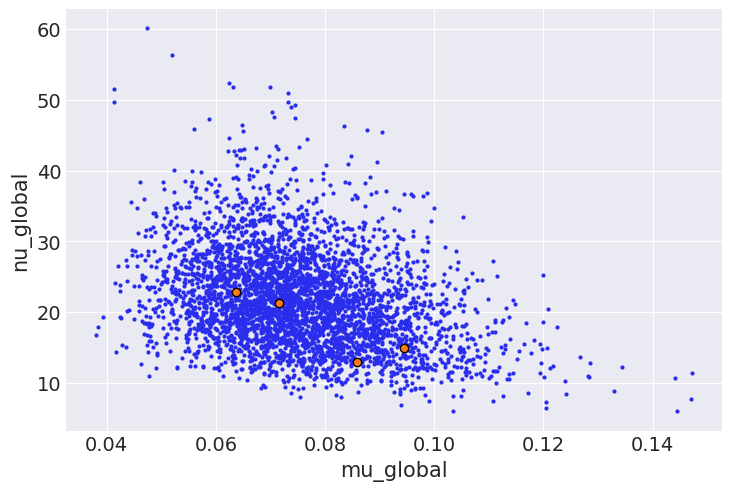

In [61]:
az.plot_pair(
    idata_multilevel,
    var_names=["mu_global", "nu_global"],
    kind="scatter",
    divergences=True
)

plt.show()

### Posterior predictive check

Output()

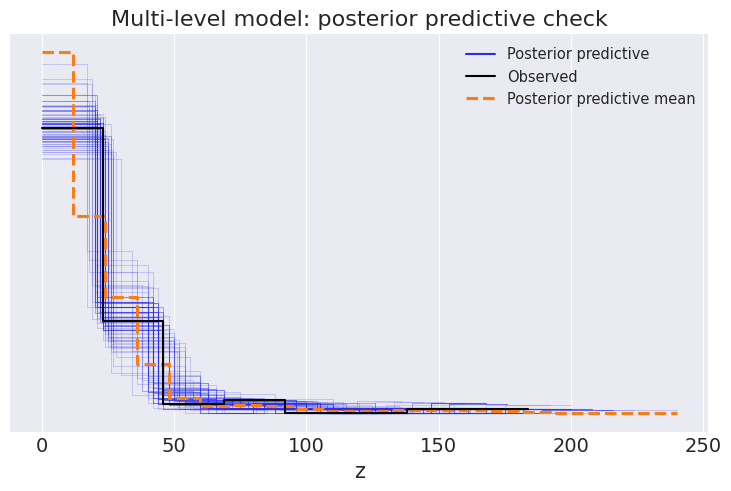

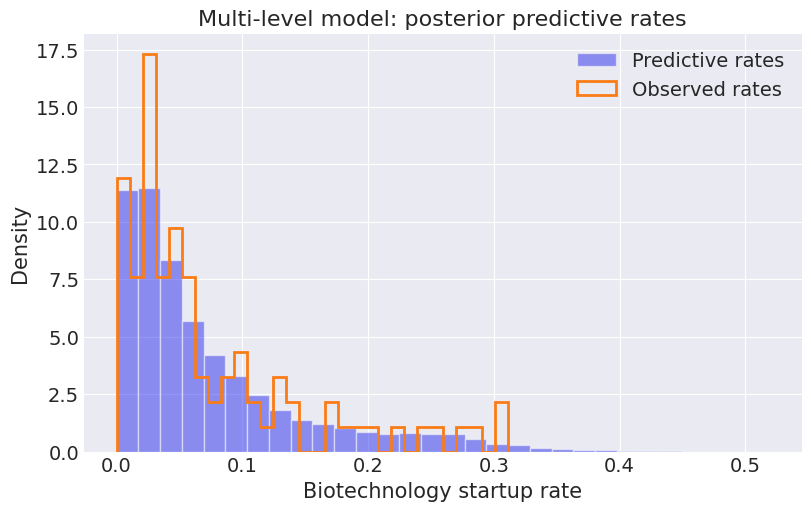

In [62]:
# Posterior predictive check

with multilevel_model:
    idata_multilevel = pm.sample_posterior_predictive(
        idata_multilevel,
        var_names=["z"],
        random_seed=random_seed,
        extend_inferencedata=True
    )

az.plot_ppc(
    idata_multilevel,
    group="posterior",
    observed=True,
    num_pp_samples=100
)

plt.title("Multi-level model: posterior predictive check")
plt.show()

plot_predictive_rates(
    idata=idata_multilevel,
    group_name="posterior_predictive",
    n_trials=city_n_startups,
    observed_rates=city_observed_rate,
    title="Multi-level model: posterior predictive rates"
)

### Posterior

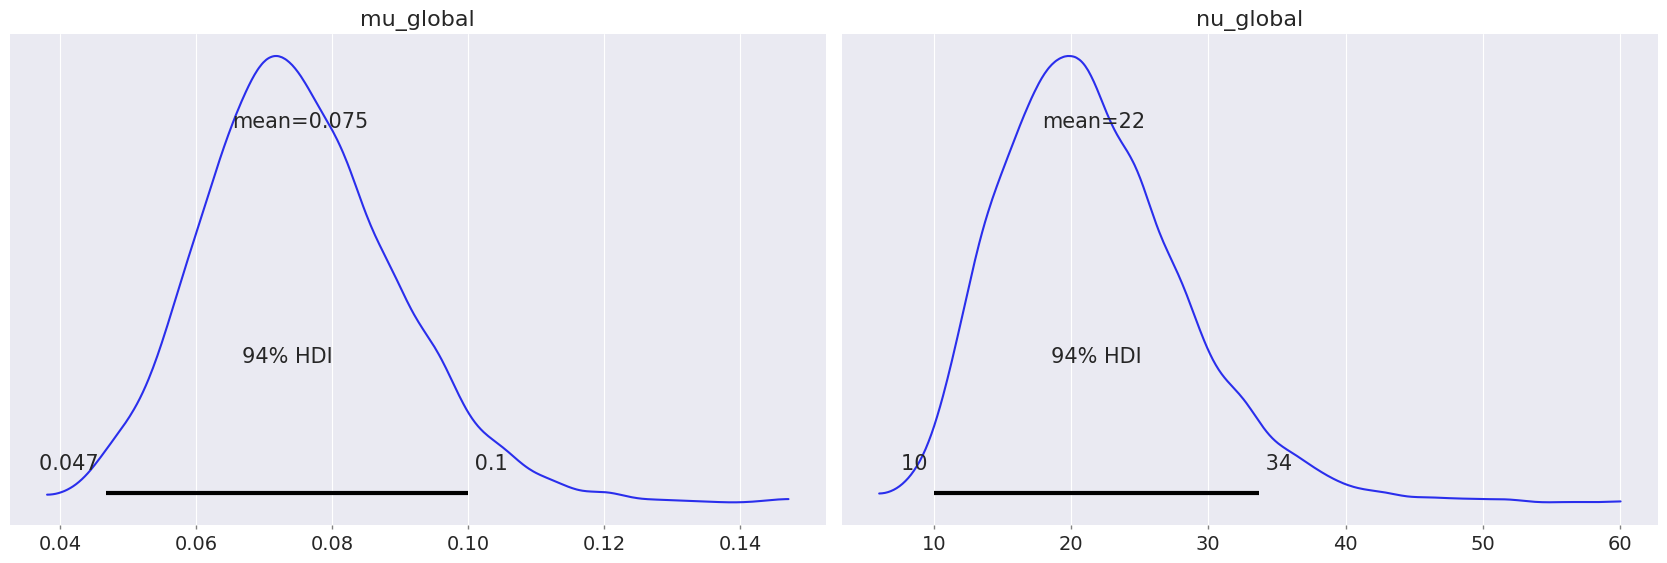

In [63]:
# Global hyperparameters
az.plot_posterior(
    idata_multilevel,
    var_names=["mu_global", "nu_global"]
)

plt.show()


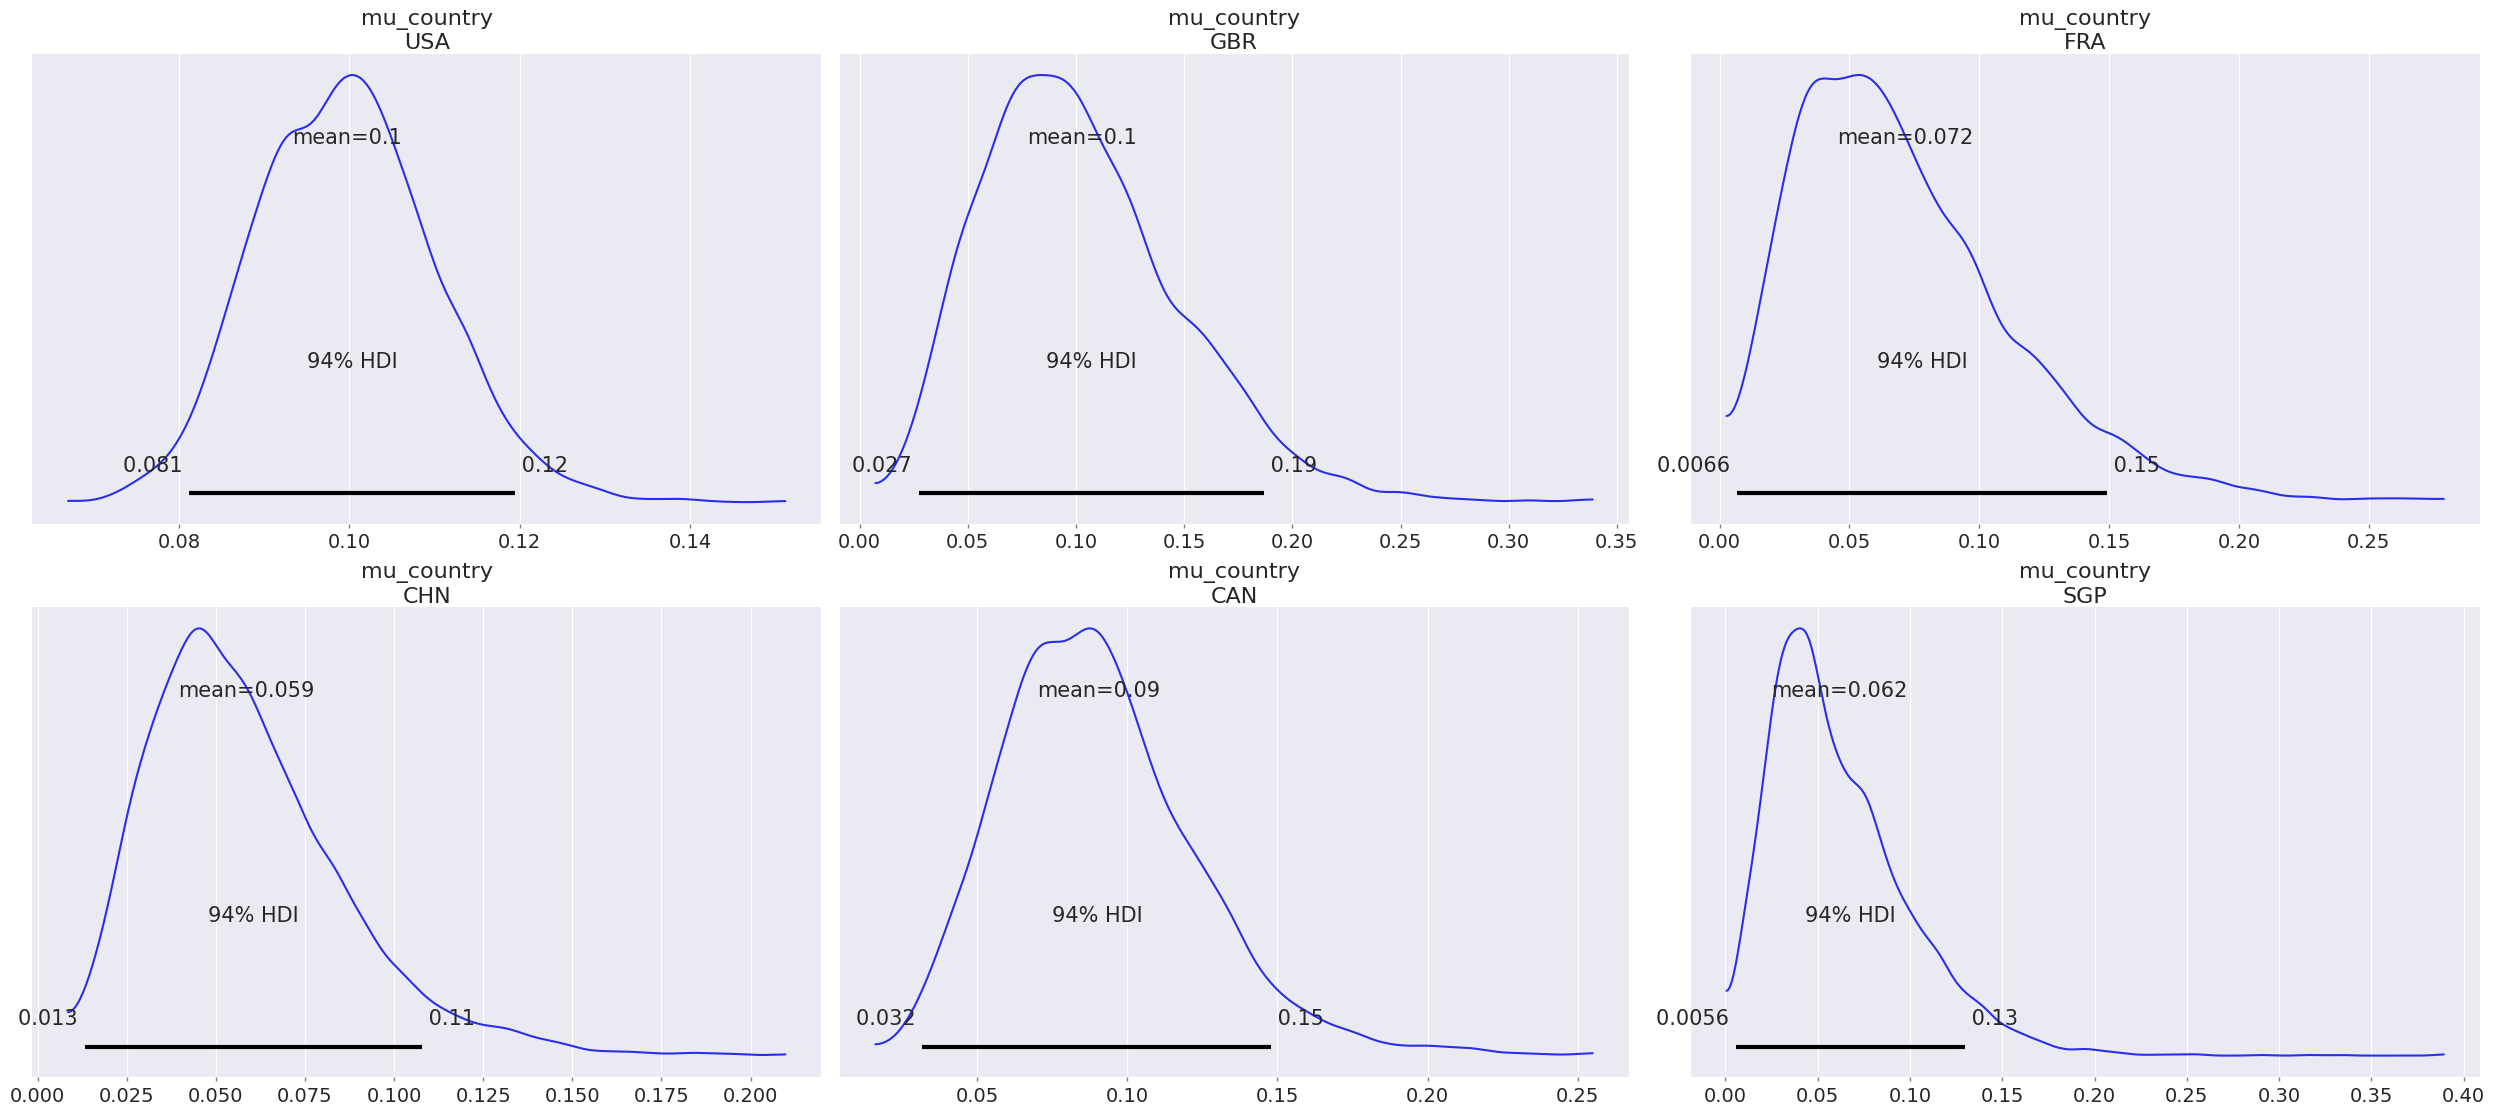

In [64]:
# Country level hyperparameters
az.plot_posterior(
    idata_multilevel,
    var_names=["mu_country"],
    coords={"country": country_codes_multilevel[:6]})

plt.show()

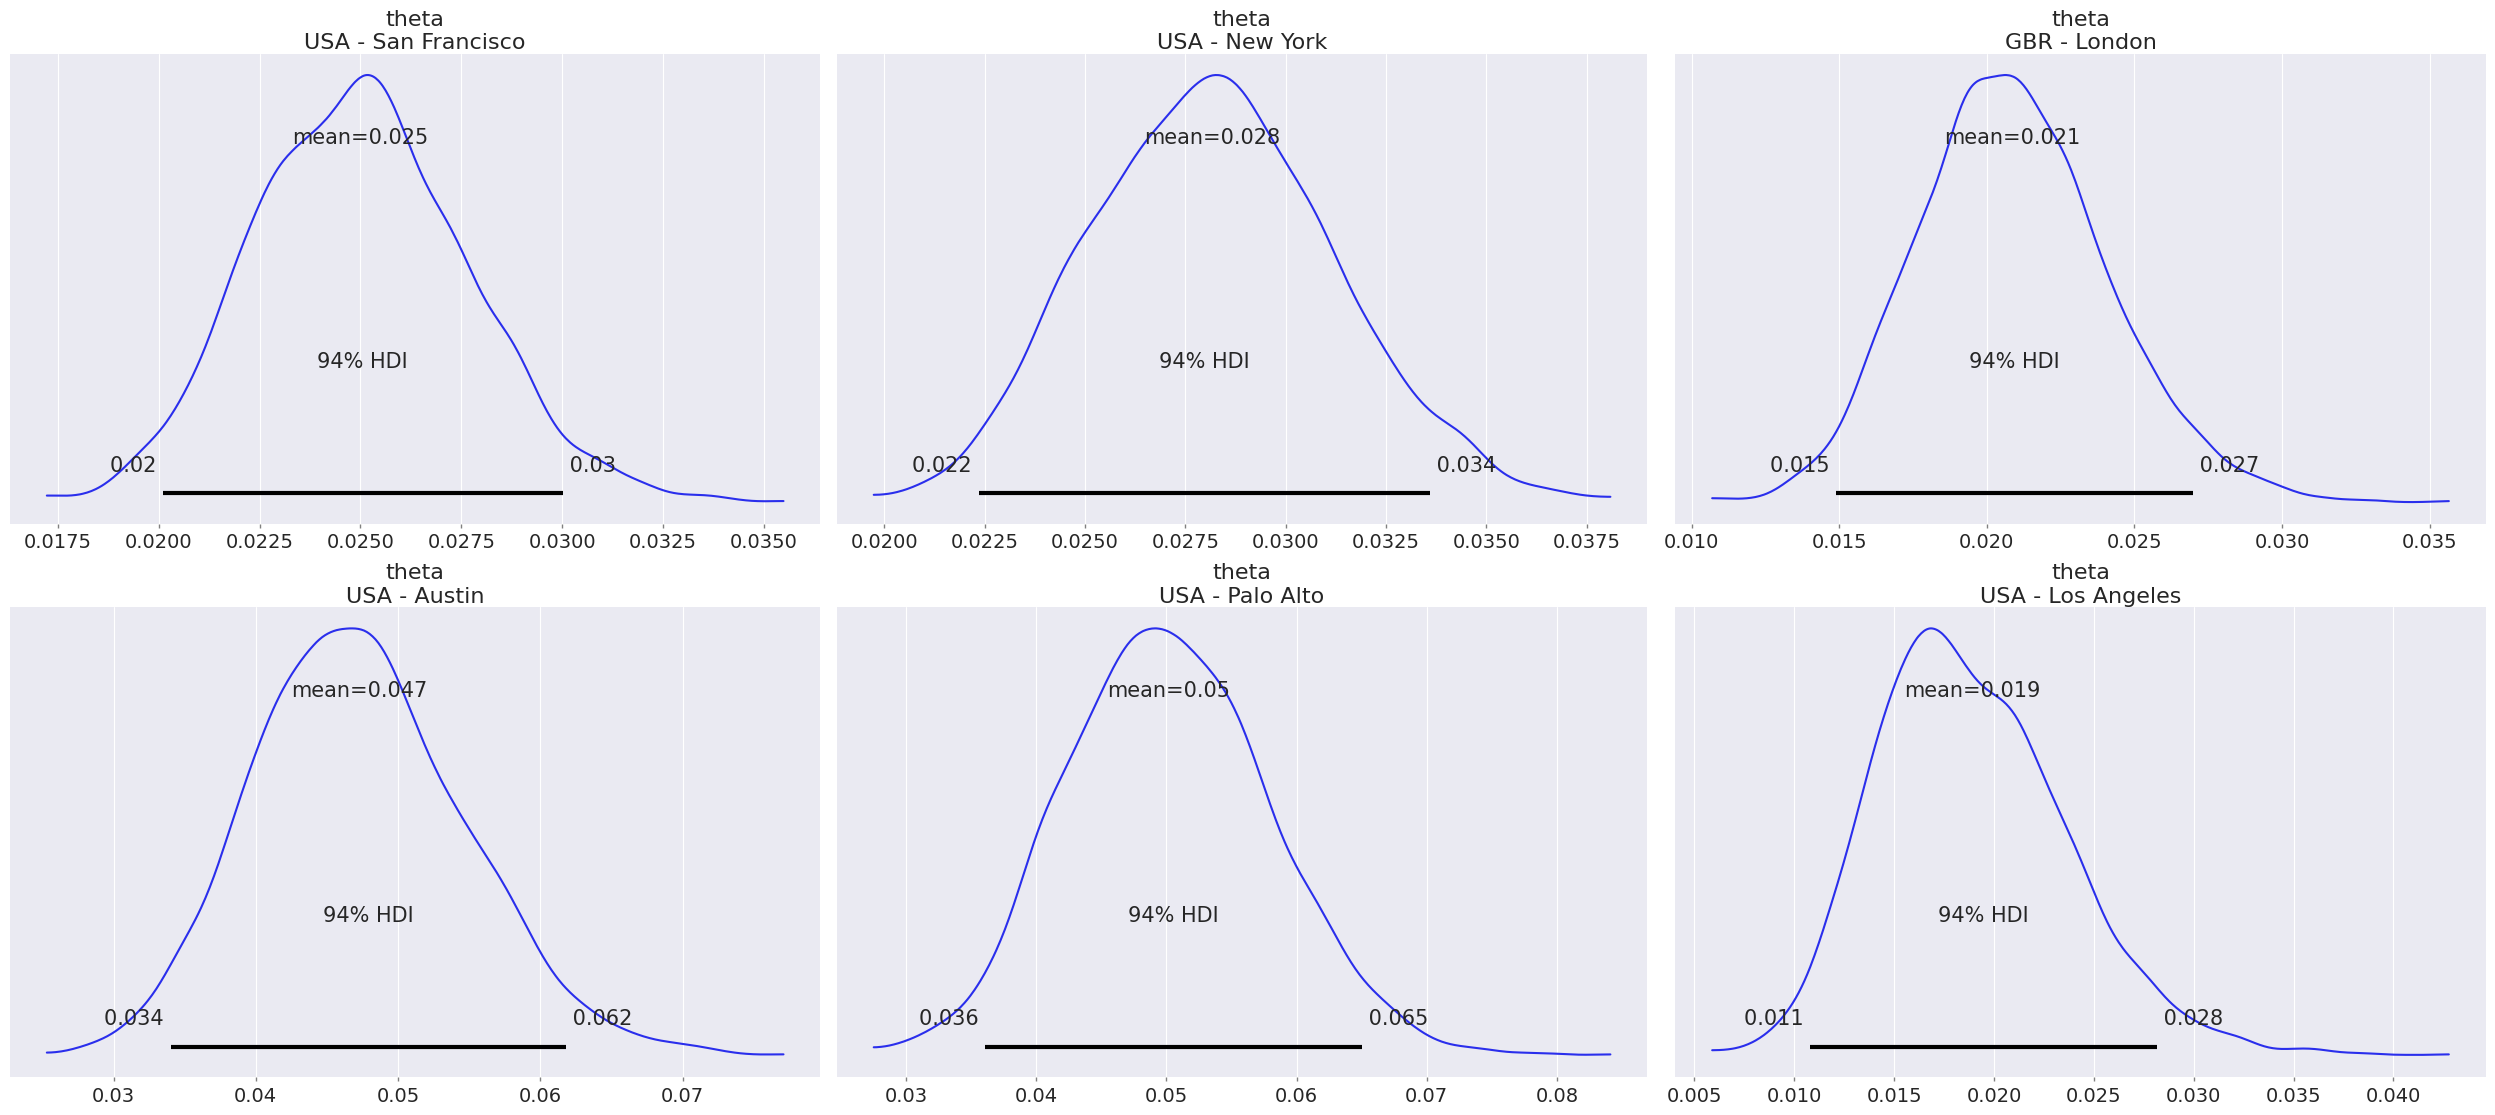

In [65]:
# City level parameter
az.plot_posterior(
    idata_multilevel,
    var_names=["theta"],
    coords={"city": selected_cities},
    hdi_prob=0.94
)

plt.show()

/tmp/ipykernel_590/1846157906.py:270: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


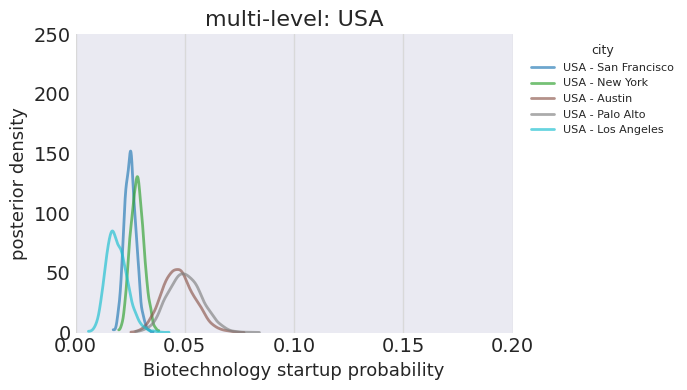

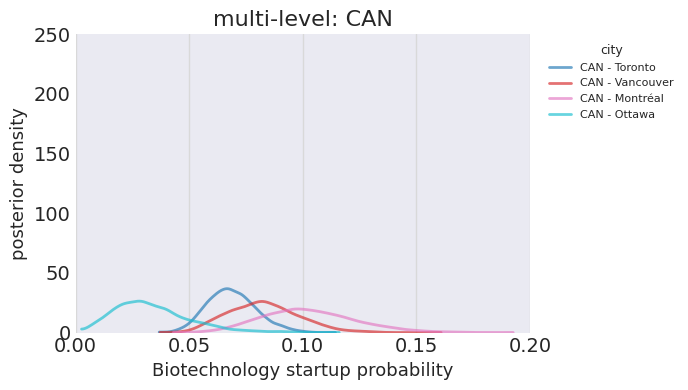

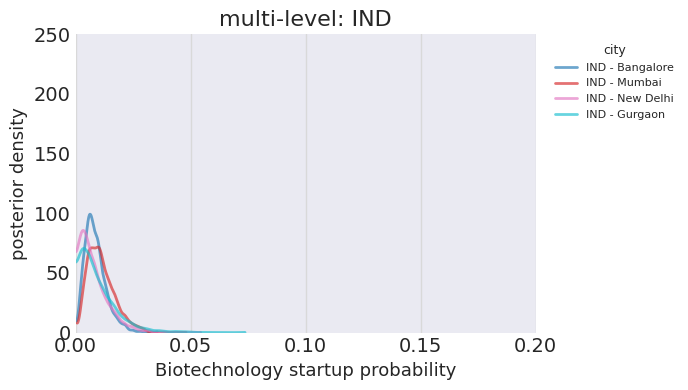

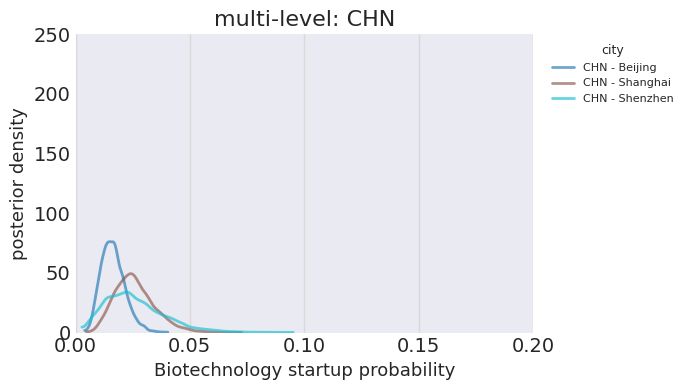

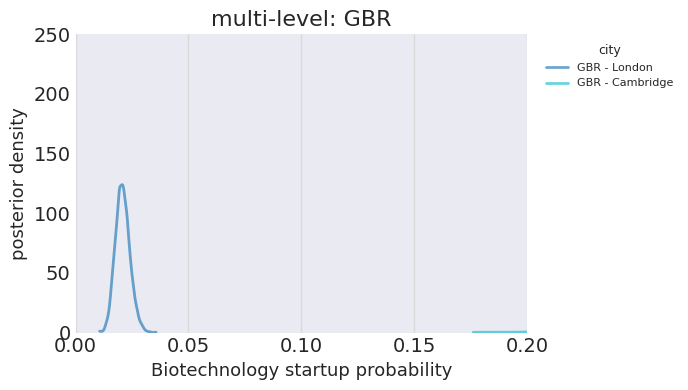

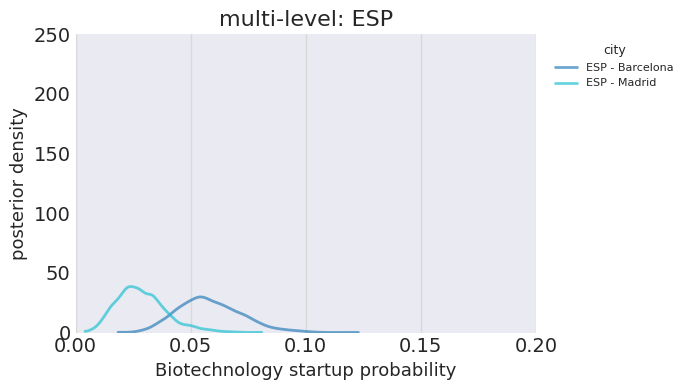

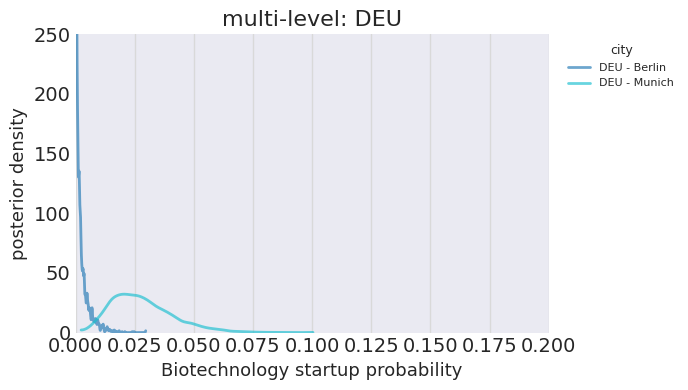

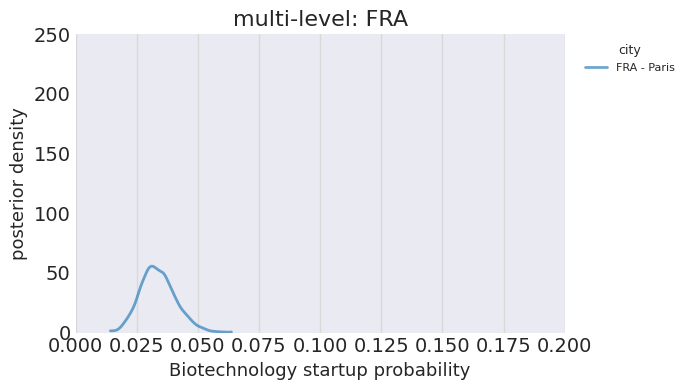

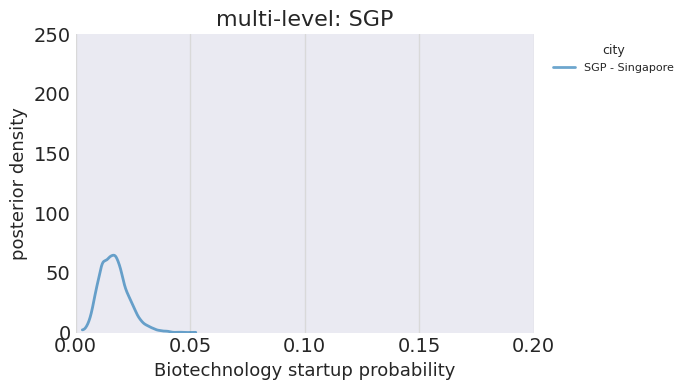

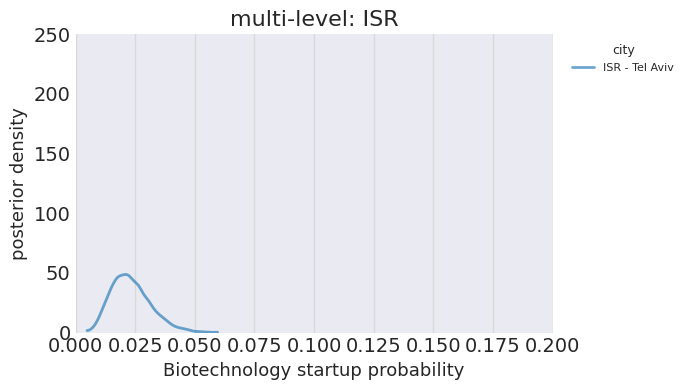

/tmp/ipykernel_590/1846157906.py:273: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 720x480 with 0 Axes>

In [85]:
# Multi-level model: city-level theta.
plot_multilevel_by_country(
    idata=idata_multilevel,
    city_names=city_names,
    city_country=city_country,
    n_countries=10,
    max_cities_per_country=5,
    xlim=(0, 0.20),
    ylim=(0, 250)
)